## Mesh align

In [54]:
import open3d as o3d

In [55]:
mesh1 = o3d.io.read_triangle_mesh("/media/desktop/ARVEEN - CT DATA/MicroCT/Prof. Tushar/new/Reconstructed_Meshes/lko/Mesh_6.ply")
mesh2 = o3d.io.read_triangle_mesh("/media/desktop/ARVEEN - CT DATA/MicroCT/Prof. Tushar/new/Reconstructed_Meshes/wt/Mesh_4.ply")

mesh1.compute_triangle_normals()
mesh2.compute_triangle_normals()

mesh1.compute_vertex_normals()
mesh2.compute_vertex_normals()

TriangleMesh with 488260 points and 971054 triangles.

In [56]:
mesh1.paint_uniform_color([1, 0, 0])
mesh2.paint_uniform_color([0,0,1])

o3d.visualization.draw_geometries([mesh1, mesh2])

In [57]:
import open3d as o3d
import numpy as np

# -----------------------------
# Utility: PCA
# -----------------------------
def get_pca_axes(mesh):
    points = np.asarray(mesh.vertices)
    centroid = points.mean(axis=0)

    points_centered = points - centroid
    cov = np.cov(points_centered.T)

    eigvals, eigvecs = np.linalg.eigh(cov)
    order = np.argsort(eigvals)[::-1]
    eigvecs = eigvecs[:, order]

    return centroid, eigvecs, points


# -----------------------------
# Utility: local thickness proxy
# -----------------------------
def estimate_local_radius(points, k=20):
    from sklearn.neighbors import NearestNeighbors
    
    nbrs = NearestNeighbors(n_neighbors=k).fit(points)
    distances, _ = nbrs.kneighbors(points)

    # mean neighbor distance as proxy
    radii = distances.mean(axis=1)
    return radii


# -----------------------------
# Utility: straightness
# -----------------------------
def straightness(region):
    if len(region) < 10:
        return 0
    cov = np.cov(region.T)
    eigvals, _ = np.linalg.eigh(cov)
    eigvals = np.sort(eigvals)
    return eigvals[-1] / (eigvals.sum() + 1e-8)


# -----------------------------
# Utility: spread (branchiness proxy)
# -----------------------------
def spread(region):
    if len(region) < 10:
        return 0
    return np.mean(np.linalg.norm(region - region.mean(axis=0), axis=1))


# -----------------------------
# MAIN: Detect A-P direction
# -----------------------------
def detect_AP_axis(mesh):

    centroid, axes, points = get_pca_axes(mesh)

    major_axis = axes[:, 0]
    minor_axis = axes[:, 2]

    # Project points onto major axis
    proj = (points - centroid) @ major_axis

    # Split ends
    k = int(0.1 * len(points))  # top 10%
    idx_sorted = np.argsort(proj)

    end1_idx = idx_sorted[:k]
    end2_idx = idx_sorted[-k:]

    end1 = points[end1_idx]
    end2 = points[end2_idx]

    # Estimate radii globally (reuse later)
    radii = estimate_local_radius(points)

    r1 = radii[end1_idx]
    r2 = radii[end2_idx]

    # -----------------------------
    # Feature computation
    # -----------------------------
    def compute_score(region, region_radii):
        s = straightness(region)
        t = np.mean(region_radii)
        sp = spread(region)

        # midline closeness (basilar clue)
        mid_dist = np.abs((region - centroid) @ minor_axis)
        mid_score = -np.mean(mid_dist)

        # weighted score
        score = (
            2.0 * s +       # straightness
            1.5 * t +       # thickness
            1.0 * mid_score -  # midline closeness
            1.0 * sp        # penalize spread
        )
        return score

    score1 = compute_score(end1, r1)
    score2 = compute_score(end2, r2)

    # -----------------------------
    # Decide orientation
    # -----------------------------
    if score1 > score2:
        posterior_dir = -major_axis
        anterior_dir  =  major_axis
    else:
        posterior_dir =  major_axis
        anterior_dir  = -major_axis

    return anterior_dir, posterior_dir, centroid

In [58]:
def visualize_AP(mesh, anterior_dir, posterior_dir, centroid):

    arrow_length = np.max(mesh.get_axis_aligned_bounding_box().get_extent()) * 0.5

    # Create line points
    points = [
        centroid,
        centroid + anterior_dir * arrow_length,
        centroid,
        centroid + posterior_dir * arrow_length
    ]

    lines = [
        [0, 1],  # anterior
        [2, 3]   # posterior
    ]

    colors = [
        [0, 1, 0],  # green = anterior
        [1, 0, 0]   # red = posterior
    ]

    line_set = o3d.geometry.LineSet()
    line_set.points = o3d.utility.Vector3dVector(points)
    line_set.lines = o3d.utility.Vector2iVector(lines)
    line_set.colors = o3d.utility.Vector3dVector(colors)

    o3d.visualization.draw_geometries([mesh, line_set])

In [59]:
import os
anterior_dir, posterior_dir, centroid = detect_AP_axis(mesh2)
visualize_AP(mesh2, anterior_dir, posterior_dir, centroid)


In [8]:
# folder_path = '/media/desktop/ARVEEN - CT DATA/MicroCT/Prof. Tushar/new/Reconstructed_Meshes/wt'
# for path in os.listdir(folder_path):
#     file_path = os.path.join(folder_path, path)
#     mesh = o3d.io.read_triangle_mesh(file_path)
#     mesh.compute_vertex_normals()

#     anterior_dir, posterior_dir, centroid = detect_AP_axis(mesh)

#     visualize_AP(mesh, anterior_dir, posterior_dir, centroid)

In [9]:
def detect_up_down(mesh):

    # -----------------------------
    # PCA
    # -----------------------------
    points = np.asarray(mesh.vertices)
    centroid = points.mean(axis=0)

    points_centered = points - centroid
    cov = np.cov(points_centered.T)

    eigvals, eigvecs = np.linalg.eigh(cov)
    order = np.argsort(eigvals)[::-1]
    eigvecs = eigvecs[:, order]

    mid_axis = eigvecs[:, 2]   # 🔥 this is your UP-DOWN candidate

    # -----------------------------
    # Project points
    # -----------------------------
    proj = (points - centroid) @ mid_axis

    k = int(0.1 * len(points))
    idx = np.argsort(proj)

    end1_idx = idx[:k]
    end2_idx = idx[-k:]

    end1 = points[end1_idx]
    end2 = points[end2_idx]

    # -----------------------------
    # Thickness proxy (simple + fast)
    # -----------------------------
    def thickness(region):
        # average distance to centroid → rough proxy
        return np.mean(np.linalg.norm(region - centroid, axis=1))

    t1 = thickness(end1)
    t2 = thickness(end2)

    # -----------------------------
    # Decide
    # -----------------------------
    if t1 < t2:
        down = -mid_axis   # more compact → DOWN
        up   =  mid_axis
    else:
        down =  mid_axis
        up   = -mid_axis

    return up, down, centroid

In [10]:
def visualize_up_down(mesh, up, down, centroid):

    scale = np.max(mesh.get_axis_aligned_bounding_box().get_extent()) * 0.5

    points = [
        centroid, centroid + up * scale,
        centroid, centroid + down * scale
    ]

    lines = [[0,1], [2,3]]

    colors = [
        [0, 1, 0],  # UP = green
        [1, 0, 0]   # DOWN = red
    ]

    line_set = o3d.geometry.LineSet()
    line_set.points = o3d.utility.Vector3dVector(points)
    line_set.lines = o3d.utility.Vector2iVector(lines)
    line_set.colors = o3d.utility.Vector3dVector(colors)

    o3d.visualization.draw_geometries([mesh, line_set])

In [11]:
up, down, centroid = detect_up_down(mesh2)
visualize_up_down(mesh2, up, down, centroid)

In [12]:
# folder_path = '/media/desktop/ARVEEN - CT DATA/MicroCT/Prof. Tushar/new/Reconstructed_Meshes/wt'
# for path in os.listdir(folder_path):
#     file_path = os.path.join(folder_path, path)
#     mesh = o3d.io.read_triangle_mesh(file_path)
#     mesh.compute_vertex_normals()
#     up, down, centroid = detect_up_down(mesh)
#     visualize_up_down(mesh, up, down, centroid)

In [13]:
def build_frame(anterior, up):
    z = anterior / np.linalg.norm(anterior)   # forward
    y = up / np.linalg.norm(up)               # up
    x = np.cross(y, z)                        # right

    x /= np.linalg.norm(x)

    # re-orthogonalize (important)
    y = np.cross(z, x)

    R = np.stack([x, y, z], axis=1)
    return R

In [14]:
def get_transform(mesh):

    anterior, posterior, c = detect_AP_axis(mesh)
    up, down, _ = detect_up_down(mesh)

    R = build_frame(anterior, up)

    return R, c

In [15]:
import copy

def align_meshes(mesh1, mesh2):

    R1, c1 = get_transform(mesh1)
    R2, c2 = get_transform(mesh2)

    # compute rotation
    R = R1 @ R2.T

    aligned = copy.deepcopy(mesh2)

    # move to origin → rotate → move to target
    aligned.translate(-c2)
    aligned.rotate(R, center=(0,0,0))
    aligned.translate(c1)

    return aligned

In [16]:
mesh1.compute_vertex_normals()
mesh2.compute_vertex_normals()

aligned_mesh2 = align_meshes(mesh1, mesh2)

o3d.visualization.draw_geometries([mesh1, aligned_mesh2])

In [17]:
import numpy as np
import open3d as o3d

T = np.eye(4)

pcdA = mesh1.sample_points_uniformly(100000)
pcdB = aligned_mesh2.sample_points_uniformly(100000)

for i in range(10):
    print(f"\nIteration {i+1}")

    # -------- Point-to-Point (coarse) --------
    reg_p2p = o3d.pipelines.registration.registration_icp(
        pcdB, pcdA,
        2.0,
        T,
        o3d.pipelines.registration.TransformationEstimationPointToPoint()
    )

    T = reg_p2p.transformation

    # -------- Estimate normals ONCE (outside loop is even better) --------
    pcdA.estimate_normals()
    pcdB.estimate_normals()

    # -------- Point-to-Plane (refinement) --------
    reg_p2l = o3d.pipelines.registration.registration_icp(
        pcdB, pcdA,
        2.0,
        T,
        o3d.pipelines.registration.TransformationEstimationPointToPlane()
    )

    T = reg_p2l.transformation

    print("Fitness:", reg_p2l.fitness, "RMSE:", reg_p2l.inlier_rmse)

# Apply final transform ONCE
pcdB.transform(T)


Iteration 1
Fitness: 1.0 RMSE: 0.00047367482917503814

Iteration 2
Fitness: 1.0 RMSE: 0.00047599508308660693

Iteration 3
Fitness: 1.0 RMSE: 0.00047574656543270883

Iteration 4
Fitness: 1.0 RMSE: 0.00047641359754613613

Iteration 5
Fitness: 1.0 RMSE: 0.0004762372707456822

Iteration 6
Fitness: 1.0 RMSE: 0.0004758121738378853

Iteration 7
Fitness: 1.0 RMSE: 0.00047647132173455096

Iteration 8
Fitness: 1.0 RMSE: 0.0004762586711588484

Iteration 9
Fitness: 1.0 RMSE: 0.00047581497747608995

Iteration 10
Fitness: 1.0 RMSE: 0.00047646258491294103


PointCloud with 100000 points.

In [18]:
mesh1.paint_uniform_color([0.5, 0, 0])  # RGB → red
aligned_mesh2.paint_uniform_color([0, 0, 0.5])

TriangleMesh with 488260 points and 971054 triangles.

In [19]:
o3d.visualization.draw_geometries([mesh1, aligned_mesh2.transform(T)])

## Scale

In [20]:
def compute_scale(mesh):
    pts = np.asarray(mesh.vertices)
    centroid = pts.mean(axis=0)
    scale = np.sqrt(np.mean(np.linalg.norm(pts - centroid, axis=1)**2))
    return scale, centroid

In [21]:
def normalize_meshes(meshes):

    ref_scale, _ = compute_scale(meshes[0])

    scaled_meshes = []

    for mesh in meshes:
        # ✅ FIX HERE
        m = o3d.geometry.TriangleMesh(mesh)

        scale, centroid = compute_scale(m)

        factor = ref_scale / (scale + 1e-8)

        m.scale(factor, center=centroid)
        scaled_meshes.append(m)

    return scaled_meshes

In [22]:
def refine_after_scaling(mesh_ref, mesh):

    pcd1 = mesh_ref.sample_points_poisson_disk(20000)
    pcd2 = mesh.sample_points_poisson_disk(20000)

    threshold = np.max(mesh_ref.get_axis_aligned_bounding_box().get_extent()) * 0.05

    reg = o3d.pipelines.registration.registration_icp(
        pcd2, pcd1, threshold, np.eye(4),
        o3d.pipelines.registration.TransformationEstimationPointToPlane()
    )

    mesh.transform(reg.transformation)
    return mesh

In [23]:
meshes_scaled = normalize_meshes([mesh1, aligned_mesh2])

meshes_refined = []
for m in meshes_scaled:
    meshes_refined.append(refine_after_scaling(meshes_scaled[0], m))

In [24]:
len(meshes_refined)

2

In [25]:
o3d.visualization.draw_geometries(meshes_refined)

## Representative candidate

In [26]:
mesh_rep = o3d.io.read_triangle_mesh("/home/desktop/Desktop/22104412_Docs/SurfaceRecon/Vein-recons/Registration/cleaned_mesh_atlas.ply")

mesh_rep.compute_triangle_normals()
mesh_rep.compute_vertex_normals()
o3d.visualization.draw_geometries([mesh_rep])

In [27]:
import open3d as o3d
import numpy as np

# -----------------------------
# Utility: PCA
# -----------------------------
def get_pca_axes(mesh):
    points = np.asarray(mesh.vertices)
    centroid = points.mean(axis=0)

    points_centered = points - centroid
    cov = np.cov(points_centered.T)

    eigvals, eigvecs = np.linalg.eigh(cov)
    order = np.argsort(eigvals)[::-1]
    eigvecs = eigvecs[:, order]

    return centroid, eigvecs, points


# -----------------------------
# Utility: local thickness proxy
# -----------------------------
def estimate_local_radius(points, k=20):
    from sklearn.neighbors import NearestNeighbors
    
    nbrs = NearestNeighbors(n_neighbors=k).fit(points)
    distances, _ = nbrs.kneighbors(points)

    # mean neighbor distance as proxy
    radii = distances.mean(axis=1)
    return radii


# -----------------------------
# Utility: straightness
# -----------------------------
def straightness(region):
    if len(region) < 10:
        return 0
    cov = np.cov(region.T)
    eigvals, _ = np.linalg.eigh(cov)
    eigvals = np.sort(eigvals)
    return eigvals[-1] / (eigvals.sum() + 1e-8)


# -----------------------------
# Utility: spread (branchiness proxy)
# -----------------------------
def spread(region):
    if len(region) < 10:
        return 0
    return np.mean(np.linalg.norm(region - region.mean(axis=0), axis=1))


# -----------------------------
# MAIN: Detect A-P direction
# -----------------------------
def detect_AP_axis_atlas(mesh):

    centroid, axes, points = get_pca_axes(mesh)

    major_axis = axes[:, 0]
    minor_axis = axes[:, 2]

    # Project points onto major axis
    proj = (points - centroid) @ major_axis

    # Split ends
    k = int(0.1 * len(points))  # top 10%
    idx_sorted = np.argsort(proj)

    end1_idx = idx_sorted[:k]
    end2_idx = idx_sorted[-k:]

    end1 = points[end1_idx]
    end2 = points[end2_idx]

    # Estimate radii globally (reuse later)
    radii = estimate_local_radius(points)

    r1 = radii[end1_idx]
    r2 = radii[end2_idx]

    # -----------------------------
    # Feature computation
    # -----------------------------
    def compute_score(region, region_radii):
        s = straightness(region)
        t = np.mean(region_radii)
        sp = spread(region)

        # midline closeness (basilar clue)
        mid_dist = np.abs((region - centroid) @ minor_axis)
        mid_score = -np.mean(mid_dist)

        # weighted score
        score = (
            2.0 * s +       # straightness
            1.5 * t +       # thickness
            1.0 * mid_score -  # midline closeness
            1.0 * sp        # penalize spread
        )
        return score

    score1 = compute_score(end1, r1)
    score2 = compute_score(end2, r2)

    # -----------------------------
    # Decide orientation
    # -----------------------------
    if score1 > score2:
        posterior_dir = -major_axis
        anterior_dir  =  major_axis
    else:
        posterior_dir =  major_axis
        anterior_dir  = -major_axis

    return anterior_dir, posterior_dir, centroid

In [28]:
def detect_up_down_atlas(mesh):

    # -----------------------------
    # PCA
    # -----------------------------
    points = np.asarray(mesh.vertices)
    centroid = points.mean(axis=0)

    points_centered = points - centroid
    cov = np.cov(points_centered.T)

    eigvals, eigvecs = np.linalg.eigh(cov)
    order = np.argsort(eigvals)[::-1]
    eigvecs = eigvecs[:, order]

    mid_axis = eigvecs[:, 2]   # 🔥 this is your UP-DOWN candidate

    # -----------------------------
    # Project points
    # -----------------------------
    proj = (points - centroid) @ mid_axis

    k = int(0.1 * len(points))
    idx = np.argsort(proj)

    end1_idx = idx[:k]
    end2_idx = idx[-k:]

    end1 = points[end1_idx]
    end2 = points[end2_idx]

    # -----------------------------
    # Thickness proxy (simple + fast)
    # -----------------------------
    # def thickness(region):
    #     # average distance to centroid → rough proxy
    #     return np.mean(np.linalg.norm(region - centroid, axis=1))

    def thickness(region, axis):
    # remove axis component → keep perpendicular spread
        proj = (region @ axis)[:, None] * axis
        perp = region - proj
        return np.mean(np.linalg.norm(perp, axis=1))

    t1 = thickness(end1 - centroid, mid_axis)
    t2 = thickness(end2 - centroid, mid_axis)

    # -----------------------------
    # Decide
    # -----------------------------
    if t1 > t2:
        down = -mid_axis   # more compact → DOWN
        up   =  mid_axis
    else:
        down =  mid_axis
        up   = -mid_axis

    return up, down, centroid

In [29]:
def get_transform_atlas(mesh_rep):

    anterior, posterior, c = detect_AP_axis_atlas(mesh_rep)
    up, down, _ = detect_up_down_atlas(mesh_rep)

    R = build_frame(anterior, up)

    return R, c

In [30]:
import copy

def align_meshes_atlas(mesh_rep, mesh2):

    R1, c1 = get_transform_atlas(mesh_rep)
    R2, c2 = get_transform(mesh2)

    # compute rotation
    R = R1 @ R2.T

    aligned = copy.deepcopy(mesh2)

    # move to origin → rotate → move to target
    aligned.translate(-c2)
    aligned.rotate(R, center=(0,0,0))
    aligned.translate(c1)

    return aligned

In [31]:
def compute_scale(mesh):
    pts = np.asarray(mesh.vertices)
    centroid = pts.mean(axis=0)
    scale = np.sqrt(np.mean(np.linalg.norm(pts - centroid, axis=1)**2))
    return scale, centroid

In [32]:
import copy
import numpy as np

def normalize_to_reference(ref_mesh, target_mesh):
    
    ref_scale, ref_centroid = compute_scale(ref_mesh)
    
    m = copy.deepcopy(target_mesh)
    scale, centroid = compute_scale(m)

    # Step 1: scale around its own centroid
    factor = ref_scale / (scale + 1e-8)
    m.scale(factor, center=centroid)

    # Step 2: translate to match reference centroid
    m.translate(ref_centroid - centroid)

    return m

In [33]:
def registeration_atlas_basic(mesh1, mesh_rep):
    meshes_scaled = normalize_to_reference(mesh1, mesh_rep)
    meshes_scaled.compute_vertex_normals()
    mesh1.compute_vertex_normals()

    aligned_mesh2 = align_meshes_atlas(meshes_scaled, mesh1)

    T = np.eye(4)

    pcdA = meshes_scaled.sample_points_uniformly(100000)
    pcdB = aligned_mesh2.sample_points_uniformly(100000)

    for i in range(10):

        # -------- Point-to-Point (coarse) --------
        reg_p2p = o3d.pipelines.registration.registration_icp(
            pcdB, pcdA,
            2.0,
            T,
            o3d.pipelines.registration.TransformationEstimationPointToPoint()
        )

        T = reg_p2p.transformation

        # -------- Estimate normals ONCE (outside loop is even better) --------
        pcdA.estimate_normals()
        pcdB.estimate_normals()

        # -------- Point-to-Plane (refinement) --------
        reg_p2l = o3d.pipelines.registration.registration_icp(
            pcdB, pcdA,
            2.0,
            T,
            o3d.pipelines.registration.TransformationEstimationPointToPlane()
        )

        T = reg_p2l.transformation

    print("Fitness:", reg_p2l.fitness, "RMSE:", reg_p2l.inlier_rmse)

    # Apply final transform ONCE
    pcdB.transform(T)

    meshes_scaled.paint_uniform_color([0.5, 0, 0])  # RGB → red
    aligned_mesh2.paint_uniform_color([0, 0, 0.5])

    aligned_mesh2.transform(T)

    o3d.visualization.draw_geometries([meshes_scaled, aligned_mesh2 ])

    return meshes_scaled, aligned_mesh2

    
# o3d.visualization.draw_geometries([meshes_scaled, mesh1])

In [34]:
import os
anterior_dir, posterior_dir, centroid = detect_AP_axis_atlas(meshes_scaled)
visualize_AP(meshes_scaled, anterior_dir, posterior_dir, centroid)


up, down, centroid = detect_up_down_atlas(meshes_scaled)
visualize_up_down(meshes_scaled, up, down, centroid)


AttributeError: 'list' object has no attribute 'vertices'

In [ ]:
meshes_scaled.compute_vertex_normals()
mesh1.compute_vertex_normals()

aligned_mesh2 = align_meshes_atlas(meshes_scaled, mesh1)

o3d.visualization.draw_geometries([meshes_scaled, aligned_mesh2])

In [ ]:
import numpy as np
import open3d as o3d

T = np.eye(4)

pcdA = meshes_scaled.sample_points_uniformly(100000)
pcdB = aligned_mesh2.sample_points_uniformly(100000)

for i in range(10):
    print(f"\nIteration {i+1}")

    # -------- Point-to-Point (coarse) --------
    reg_p2p = o3d.pipelines.registration.registration_icp(
        pcdB, pcdA,
        2.0,
        T,
        o3d.pipelines.registration.TransformationEstimationPointToPoint()
    )

    T = reg_p2p.transformation

    # -------- Estimate normals ONCE (outside loop is even better) --------
    pcdA.estimate_normals()
    pcdB.estimate_normals()

    # -------- Point-to-Plane (refinement) --------
    reg_p2l = o3d.pipelines.registration.registration_icp(
        pcdB, pcdA,
        2.0,
        T,
        o3d.pipelines.registration.TransformationEstimationPointToPlane()
    )

    T = reg_p2l.transformation

    print("Fitness:", reg_p2l.fitness, "RMSE:", reg_p2l.inlier_rmse)

# Apply final transform ONCE
pcdB.transform(T)


Iteration 1
Fitness: 1.0 RMSE: 0.00039051368858667015

Iteration 2
Fitness: 1.0 RMSE: 0.00039004421741185304

Iteration 3
Fitness: 1.0 RMSE: 0.0003898856382195781

Iteration 4
Fitness: 1.0 RMSE: 0.00039014933245113754

Iteration 5
Fitness: 1.0 RMSE: 0.00039055823372452237

Iteration 6
Fitness: 1.0 RMSE: 0.0003909153700798844

Iteration 7
Fitness: 1.0 RMSE: 0.00039116590652735173

Iteration 8
Fitness: 1.0 RMSE: 0.00039136731643425146

Iteration 9
Fitness: 1.0 RMSE: 0.0003915205711071659

Iteration 10
Fitness: 1.0 RMSE: 0.00039163586845782365


PointCloud with 100000 points.

In [ ]:
meshes_scaled.paint_uniform_color([0.5, 0, 0])  # RGB → red
aligned_mesh2.paint_uniform_color([0, 0, 0.5])

TriangleMesh with 222982 points and 442994 triangles.

In [ ]:
o3d.visualization.draw_geometries([meshes_scaled, aligned_mesh2.transform(T)])

## LBO

In [40]:

import open3d as o3d

mesh1 = o3d.io.read_triangle_mesh("/media/desktop/ARVEEN - CT DATA/MicroCT/Prof. Tushar/new/Reconstructed_Meshes/lko/Mesh_1.ply")
mesh2 = o3d.io.read_triangle_mesh("/media/desktop/ARVEEN - CT DATA/MicroCT/Prof. Tushar/new/Reconstructed_Meshes/wt/Mesh_6.ply")

In [41]:
import numpy as np
import open3d as o3d
from scipy.spatial import cKDTree


# -----------------------------
# Sample points from mesh
# -----------------------------
def sample_points(mesh, n=10000):
    pcd = mesh.sample_points_uniformly(number_of_points=n)
    return np.asarray(pcd.points)


# -----------------------------
# Directed Hausdorff
# -----------------------------
def directed_hausdorff(A, B):
    tree = cKDTree(B)
    dists, _ = tree.query(A)
    return np.max(dists)


# -----------------------------
# Symmetric Hausdorff
# -----------------------------
def hausdorff_distance(meshA, meshB, n=10000):
    A = sample_points(meshA, n)
    B = sample_points(meshB, n)

    d_AB = directed_hausdorff(A, B)
    d_BA = directed_hausdorff(B, A)

    return max(d_AB, d_BA)

def chamfer_distance(meshA, meshB, n=10000):
    A = sample_points(meshA, n)
    B = sample_points(meshB, n)

    tree_A = cKDTree(A)
    tree_B = cKDTree(B)

    d_AB, _ = tree_B.query(A)
    d_BA, _ = tree_A.query(B)

    return np.mean(d_AB) + np.mean(d_BA)

In [42]:
import os
path  = []
parent_folder_path_wt = "/media/desktop/ARVEEN - CT DATA/MicroCT/Prof. Tushar/new/Reconstructed_Meshes/wt"
parent_folder_path_lko = "/media/desktop/ARVEEN - CT DATA/MicroCT/Prof. Tushar/new/Reconstructed_Meshes/lko"

for path_wt in os.listdir(parent_folder_path_wt):
    path.append(os.path.join(parent_folder_path_wt, path_wt))

for path_lko in os.listdir(parent_folder_path_lko):
    path.append(os.path.join(parent_folder_path_lko, path_lko))

In [43]:
def registration(mesh1, mesh2, window_title):
    mesh1.compute_triangle_normals()
    mesh2.compute_triangle_normals()

    mesh1.compute_vertex_normals()
    mesh2.compute_vertex_normals()

    aligned_mesh2 = align_meshes(mesh1, mesh2)
    meshes_scaled = normalize_meshes([mesh1, aligned_mesh2])
    mesh1 = meshes_scaled[0]
    aligned_mesh2 = meshes_scaled[1]
    
    T = np.eye(4)

    pcdA = mesh1.sample_points_uniformly(100000)
    pcdB = aligned_mesh2.sample_points_uniformly(100000)

    for i in range(10):
        # print(f"\nIteration {i+1}")

        # -------- Point-to-Point (coarse) --------
        reg_p2p = o3d.pipelines.registration.registration_icp(
            pcdB, pcdA,
            2.0,
            T,
            o3d.pipelines.registration.TransformationEstimationPointToPoint()
        )

        T = reg_p2p.transformation

        # -------- Estimate normals ONCE (outside loop is even better) --------
        pcdA.estimate_normals()
        pcdB.estimate_normals()

        # -------- Point-to-Plane (refinement) --------
        reg_p2l = o3d.pipelines.registration.registration_icp(
            pcdB, pcdA,
            2.0,
            T,
            o3d.pipelines.registration.TransformationEstimationPointToPlane()
        )

        T = reg_p2l.transformation

    
    print("Fitness:", reg_p2l.fitness, "RMSE:", reg_p2l.inlier_rmse)

    # Apply final transform ONCE
    pcdB.transform(T)

    aligned_mesh2.transform(T)
    mesh2 = aligned_mesh2

    mesh1.paint_uniform_color([0.5, 0, 0])
    mesh2.paint_uniform_color([0,0,0.5])
    # o3d.visualization.draw_geometries([mesh1, mesh2])

#     o3d.visualization.draw_geometries(
#         [mesh1, mesh2],
#         window_name=window_title
# )
    
    return mesh1, mesh2

In [45]:
path

['/media/desktop/ARVEEN - CT DATA/MicroCT/Prof. Tushar/new/Reconstructed_Meshes/wt/Mesh_1.ply',
 '/media/desktop/ARVEEN - CT DATA/MicroCT/Prof. Tushar/new/Reconstructed_Meshes/wt/Mesh_2.ply',
 '/media/desktop/ARVEEN - CT DATA/MicroCT/Prof. Tushar/new/Reconstructed_Meshes/wt/Mesh_3.ply',
 '/media/desktop/ARVEEN - CT DATA/MicroCT/Prof. Tushar/new/Reconstructed_Meshes/wt/Mesh_4.ply',
 '/media/desktop/ARVEEN - CT DATA/MicroCT/Prof. Tushar/new/Reconstructed_Meshes/wt/Mesh_6.ply',
 '/media/desktop/ARVEEN - CT DATA/MicroCT/Prof. Tushar/new/Reconstructed_Meshes/lko/Mesh_1.ply',
 '/media/desktop/ARVEEN - CT DATA/MicroCT/Prof. Tushar/new/Reconstructed_Meshes/lko/Mesh_2.ply',
 '/media/desktop/ARVEEN - CT DATA/MicroCT/Prof. Tushar/new/Reconstructed_Meshes/lko/Mesh_3.ply',
 '/media/desktop/ARVEEN - CT DATA/MicroCT/Prof. Tushar/new/Reconstructed_Meshes/lko/Mesh_5.ply',
 '/media/desktop/ARVEEN - CT DATA/MicroCT/Prof. Tushar/new/Reconstructed_Meshes/lko/Mesh_6.ply']

In [46]:
import open3d as o3d
import numpy as np
import os
import copy


def frame_generation(meshA, meshB, window_name, n_frames=120):

    folder = window_name.replace(" ", "_")
    os.makedirs(folder, exist_ok=True)

    # -----------------------------
    # Deep copy (IMPORTANT)
    # -----------------------------
    

    meshA.compute_triangle_normals()
    meshB.compute_triangle_normals()

    meshA.compute_vertex_normals()
    meshB.compute_vertex_normals()

    baseA = copy.deepcopy(meshA)
    baseB = copy.deepcopy(meshB)
    
    baseA.paint_uniform_color([1, 0, 0])
    baseB.paint_uniform_color([0, 0, 1])

    # -----------------------------
    # Visualizer
    # -----------------------------
    vis = o3d.visualization.Visualizer()
    vis.create_window()

    vis.add_geometry(baseA)
    vis.add_geometry(baseB)

    # Center of rotation
    center = baseA.get_center()

    # -----------------------------
    # Frame generation
    # -----------------------------
    for i in range(n_frames):

        # angle per frame
        angle = 2 * np.pi / n_frames

        # rotation matrix (around Z axis)
        R = baseA.get_rotation_matrix_from_xyz((0, angle, 0))

        baseA.rotate(R, center=center)
        baseB.rotate(R, center=center)

        vis.update_geometry(baseA)
        vis.update_geometry(baseB)

        vis.poll_events()
        vis.update_renderer()
        
        filename = os.path.join(folder, f"frame_{i:04d}.png")
        vis.capture_screen_image(filename)

    vis.destroy_window()

In [47]:
meshes = [o3d.io.read_triangle_mesh(p) for p in path]

names = [
    os.path.basename(os.path.dirname(p)) + "_" +
    os.path.splitext(os.path.basename(p))[0]
    for p in path
]

N = len(meshes)
dist_tot = np.zeros((N, N))

# -----------------------------
# Compute pairwise distances
# -----------------------------
for i in range(N):
    for j in range(N):
        print(f"{names[i]} vs {names[j]}")
        meshA, meshB = registration(meshes[i], meshes[j], f"{names[i]} vs {names[j]}")
        d = chamfer_distance(meshA, meshB)
        dist_tot[i, j] = d
        # frame_generation(meshA, meshB, f"{names[i]} vs {names[j]}")
    print(f"Completed {i} Mesh")

wt_Mesh_1 vs wt_Mesh_1
Fitness: 1.0 RMSE: 3.60628780921087e-05
wt_Mesh_1 vs wt_Mesh_2
Fitness: 1.0 RMSE: 0.00026920278317247405
wt_Mesh_1 vs wt_Mesh_3
Fitness: 1.0 RMSE: 0.000288728564370995
wt_Mesh_1 vs wt_Mesh_4
Fitness: 1.0 RMSE: 0.0003233770108491788
wt_Mesh_1 vs wt_Mesh_6
Fitness: 1.0 RMSE: 0.0003485892974692308
wt_Mesh_1 vs lko_Mesh_1
Fitness: 1.0 RMSE: 0.0002695324133943213
wt_Mesh_1 vs lko_Mesh_2
Fitness: 1.0 RMSE: 0.0002855861044829136
wt_Mesh_1 vs lko_Mesh_3
Fitness: 1.0 RMSE: 0.0002548277405229328
wt_Mesh_1 vs lko_Mesh_5
Fitness: 1.0 RMSE: 0.00020354900680180077
wt_Mesh_1 vs lko_Mesh_6
Fitness: 1.0 RMSE: 0.00032653710297883396
Completed 0 Mesh
wt_Mesh_2 vs wt_Mesh_1
Fitness: 1.0 RMSE: 0.0002575277298377489
wt_Mesh_2 vs wt_Mesh_2
Fitness: 1.0 RMSE: 3.0301506690353747e-05
wt_Mesh_2 vs wt_Mesh_3
Fitness: 1.0 RMSE: 0.0002772253737774242
wt_Mesh_2 vs wt_Mesh_4
Fitness: 1.0 RMSE: 0.00029302964440202414
wt_Mesh_2 vs wt_Mesh_6
Fitness: 1.0 RMSE: 0.000299735619020474
wt_Mesh_2 vs lko

In [48]:
row_min = dist_tot.min(axis=1, keepdims=True)
row_max = dist_tot.max(axis=1, keepdims=True)

dist_norm = (dist_tot - row_min) / (row_max - row_min + 1e-8)

In [49]:
dist_norm.shape

(10, 10)

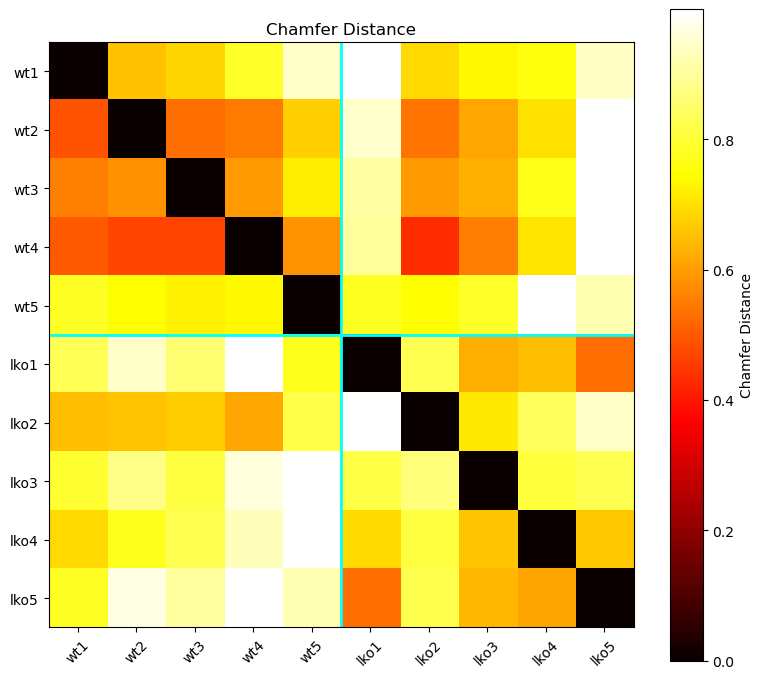

In [50]:
labels = [f"wt{i+1}" for i in range(5)] + [f"lko{i+1}" for i in range(5)]

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 7))
plt.imshow(dist_norm, cmap='hot')
plt.colorbar(label='Chamfer Distance')

plt.axhline(4.5, color='cyan', linewidth=2)
plt.axvline(4.5, color='cyan', linewidth=2)

plt.xticks(ticks=range(len(labels)), labels=labels, rotation=45)
plt.yticks(ticks=range(len(labels)), labels=labels)

plt.title("Chamfer Distance")
plt.tight_layout()
plt.show()

In [51]:
import pandas as pd

In [53]:
df_chamfer_norm = pd.DataFrame(
    dist_tot,
    index=labels,
    columns=labels
)

df_chamfer_norm.to_csv("/media/desktop/ARVEEN - CT DATA/MicroCT/Results/Chamfer_Distance/chamfer_distance_matrix_raw.csv")

print("Saved normalized Chamfer distances to chamfer_distance_matrix_raw.csv")

Saved normalized Chamfer distances to chamfer_distance_matrix_raw.csv


In [33]:
import re
import numpy as np

# log = """wt_Mesh_1 vs wt_Mesh_1
# Fitness: 1.0 RMSE: 3.009498945339391e-05
# wt_Mesh_1 vs wt_Mesh_2
# Fitness: 1.0 RMSE: 0.0002683819496526675
# wt_Mesh_1 vs wt_Mesh_3
# Fitness: 1.0 RMSE: 0.0002902891088858185
# wt_Mesh_1 vs wt_Mesh_4
# Fitness: 1.0 RMSE: 0.0003236545294734087
# wt_Mesh_1 vs wt_Mesh_6
# Fitness: 1.0 RMSE: 0.00034918188224488213
# wt_Mesh_1 vs lko_Mesh_1
# Fitness: 1.0 RMSE: 0.00027155485373422944
# wt_Mesh_1 vs lko_Mesh_2
# Fitness: 1.0 RMSE: 0.0002870716026126724
# wt_Mesh_1 vs lko_Mesh_3
# Fitness: 1.0 RMSE: 0.0002552840447315015
# wt_Mesh_1 vs lko_Mesh_5
# Fitness: 1.0 RMSE: 0.0002030629541528559
# wt_Mesh_1 vs lko_Mesh_6
# Fitness: 1.0 RMSE: 0.00033145343462525766
# Completed 0 Mesh
# wt_Mesh_2 vs wt_Mesh_1
# Fitness: 1.0 RMSE: 0.00026045979318063813
# wt_Mesh_2 vs wt_Mesh_2
# Fitness: 1.0 RMSE: 3.107234372986195e-05
# wt_Mesh_2 vs wt_Mesh_3
# Fitness: 1.0 RMSE: 0.00027767942086769873
# wt_Mesh_2 vs wt_Mesh_4
# Fitness: 1.0 RMSE: 0.00028967013128585573
# wt_Mesh_2 vs wt_Mesh_6
# Fitness: 1.0 RMSE: 0.0002987353253439809
# wt_Mesh_2 vs lko_Mesh_1
# Fitness: 1.0 RMSE: 0.0002875982897786134
# wt_Mesh_2 vs lko_Mesh_2
# Fitness: 1.0 RMSE: 0.00027422527229162193
# wt_Mesh_2 vs lko_Mesh_3
# Fitness: 1.0 RMSE: 0.000279746666591811
# wt_Mesh_2 vs lko_Mesh_5
# Fitness: 1.0 RMSE: 0.000247671777911854
# wt_Mesh_2 vs lko_Mesh_6
# Fitness: 1.0 RMSE: 0.00038909301904098783
# Completed 1 Mesh
# wt_Mesh_3 vs wt_Mesh_1
# Fitness: 1.0 RMSE: 0.0002472095083205202
# wt_Mesh_3 vs wt_Mesh_2
# Fitness: 1.0 RMSE: 0.00024691686106778236
# wt_Mesh_3 vs wt_Mesh_3
# Fitness: 1.0 RMSE: 3.085010610763349e-05
# wt_Mesh_3 vs wt_Mesh_4
# Fitness: 1.0 RMSE: 0.00027892402903844597
# wt_Mesh_3 vs wt_Mesh_6
# Fitness: 1.0 RMSE: 0.0003069794498884982
# wt_Mesh_3 vs lko_Mesh_1
# Fitness: 1.0 RMSE: 0.0002667623698449467
# wt_Mesh_3 vs lko_Mesh_2
# Fitness: 1.0 RMSE: 0.00026264756378530443
# wt_Mesh_3 vs lko_Mesh_3
# Fitness: 1.0 RMSE: 0.0002378453001517884
# wt_Mesh_3 vs lko_Mesh_5
# Fitness: 1.0 RMSE: 0.00022226880340167314
# wt_Mesh_3 vs lko_Mesh_6
# Fitness: 1.0 RMSE: 0.0003389467066853479
# Completed 2 Mesh
# wt_Mesh_4 vs wt_Mesh_1
# Fitness: 1.0 RMSE: 0.00024566088477725464
# wt_Mesh_4 vs wt_Mesh_2
# Fitness: 1.0 RMSE: 0.00023379876937161575
# wt_Mesh_4 vs wt_Mesh_3
# Fitness: 1.0 RMSE: 0.0002378210531572736
# wt_Mesh_4 vs wt_Mesh_4
# Fitness: 1.0 RMSE: 2.933159117531417e-05
# wt_Mesh_4 vs wt_Mesh_6
# Fitness: 1.0 RMSE: 0.0002921562023907107
# wt_Mesh_4 vs lko_Mesh_1
# Fitness: 1.0 RMSE: 0.0002887165654387787
# wt_Mesh_4 vs lko_Mesh_2
# Fitness: 1.0 RMSE: 0.00022715415525728595
# wt_Mesh_4 vs lko_Mesh_3
# Fitness: 1.0 RMSE: 0.00023778675898558857
# wt_Mesh_4 vs lko_Mesh_5
# Fitness: 1.0 RMSE: 0.0002378559240004974
# wt_Mesh_4 vs lko_Mesh_6
# Fitness: 1.0 RMSE: 0.000416337843346017
# Completed 3 Mesh
# wt_Mesh_6 vs wt_Mesh_1
# Fitness: 1.0 RMSE: 0.0003374619586394426
# wt_Mesh_6 vs wt_Mesh_2
# Fitness: 1.0 RMSE: 0.00032214981445543526
# wt_Mesh_6 vs wt_Mesh_3
# Fitness: 1.0 RMSE: 0.00032450206602864306
# wt_Mesh_6 vs wt_Mesh_4
# Fitness: 1.0 RMSE: 0.0003322956962464019
# wt_Mesh_6 vs wt_Mesh_6
# Fitness: 1.0 RMSE: 3.0196471486270704e-05
# wt_Mesh_6 vs lko_Mesh_1
# Fitness: 1.0 RMSE: 0.00025834201328322993
# wt_Mesh_6 vs lko_Mesh_2
# Fitness: 1.0 RMSE: 0.0003398981880993423
# wt_Mesh_6 vs lko_Mesh_3
# Fitness: 1.0 RMSE: 0.00029580972482914404
# wt_Mesh_6 vs lko_Mesh_5
# Fitness: 1.0 RMSE: 0.00029923367829636914
# wt_Mesh_6 vs lko_Mesh_6
# Fitness: 1.0 RMSE: 0.0003499538129832328
# Completed 4 Mesh
# lko_Mesh_1 vs wt_Mesh_1
# Fitness: 1.0 RMSE: 0.0004487405119803697
# lko_Mesh_1 vs wt_Mesh_2
# Fitness: 1.0 RMSE: 0.00045142957477654433
# lko_Mesh_1 vs wt_Mesh_3
# Fitness: 1.0 RMSE: 0.0004605111107699907
# lko_Mesh_1 vs wt_Mesh_4
# Fitness: 1.0 RMSE: 0.0004954999121325336
# lko_Mesh_1 vs wt_Mesh_6
# Fitness: 1.0 RMSE: 0.00047917085799603686
# lko_Mesh_1 vs lko_Mesh_1
# Fitness: 1.0 RMSE: 1.8142884570425033e-05
# lko_Mesh_1 vs lko_Mesh_2
# Fitness: 1.0 RMSE: 0.00047127358419290713
# lko_Mesh_1 vs lko_Mesh_3
# Fitness: 1.0 RMSE: 0.00035043587962208374
# lko_Mesh_1 vs lko_Mesh_5
# Fitness: 1.0 RMSE: 0.00029532264555251264
# lko_Mesh_1 vs lko_Mesh_6
# Fitness: 1.0 RMSE: 0.00032119751766155106
# Completed 5 Mesh
# lko_Mesh_2 vs wt_Mesh_1
# Fitness: 1.0 RMSE: 0.0002482065348486351
# lko_Mesh_2 vs wt_Mesh_2
# Fitness: 1.0 RMSE: 0.00025282228415374094
# lko_Mesh_2 vs wt_Mesh_3
# Fitness: 1.0 RMSE: 0.000269949825701149
# lko_Mesh_2 vs wt_Mesh_4
# Fitness: 1.0 RMSE: 0.0002650068867887452
# lko_Mesh_2 vs wt_Mesh_6
# Fitness: 1.0 RMSE: 0.00029739824986878613
# lko_Mesh_2 vs lko_Mesh_1
# Fitness: 1.0 RMSE: 0.000259958596362716
# lko_Mesh_2 vs lko_Mesh_2
# Fitness: 1.0 RMSE: 2.8864226826521e-05
# lko_Mesh_2 vs lko_Mesh_3
# Fitness: 1.0 RMSE: 0.00023530994961325918
# lko_Mesh_2 vs lko_Mesh_5
# Fitness: 1.0 RMSE: 0.00019762623721172325
# lko_Mesh_2 vs lko_Mesh_6
# Fitness: 1.0 RMSE: 0.00031922830323050203
# Completed 6 Mesh
# lko_Mesh_3 vs wt_Mesh_1
# Fitness: 1.0 RMSE: 0.00034882222413851763
# lko_Mesh_3 vs wt_Mesh_2
# Fitness: 1.0 RMSE: 0.00035341131709346393
# lko_Mesh_3 vs wt_Mesh_3
# Fitness: 1.0 RMSE: 0.0003601572042212662
# lko_Mesh_3 vs wt_Mesh_4
# Fitness: 1.0 RMSE: 0.00040142132104326603
# lko_Mesh_3 vs wt_Mesh_6
# Fitness: 1.0 RMSE: 0.0004285542491567541
# lko_Mesh_3 vs lko_Mesh_1
# Fitness: 1.0 RMSE: 0.0002733728449070018
# lko_Mesh_3 vs lko_Mesh_2
# Fitness: 1.0 RMSE: 0.000362816205537806
# lko_Mesh_3 vs lko_Mesh_3
# Fitness: 1.0 RMSE: 2.4225899182766395e-05
# lko_Mesh_3 vs lko_Mesh_5
# Fitness: 1.0 RMSE: 0.00022258801054017455
# lko_Mesh_3 vs lko_Mesh_6
# Fitness: 1.0 RMSE: 0.00034469681816555497
# Completed 7 Mesh
# lko_Mesh_5 vs wt_Mesh_1
# Fitness: 1.0 RMSE: 0.00041737767511293455
# lko_Mesh_5 vs wt_Mesh_2
# Fitness: 1.0 RMSE: 0.000446206224842714
# lko_Mesh_5 vs wt_Mesh_3
# Fitness: 1.0 RMSE: 0.00048762023583555825
# lko_Mesh_5 vs wt_Mesh_4
# Fitness: 1.0 RMSE: 0.0005479610922295565
# lko_Mesh_5 vs wt_Mesh_6
# Fitness: 1.0 RMSE: 0.0005580828944141774
# lko_Mesh_5 vs lko_Mesh_1
# Fitness: 1.0 RMSE: 0.0003618099338031228
# lko_Mesh_5 vs lko_Mesh_2
# Fitness: 1.0 RMSE: 0.0004963535355681338
# lko_Mesh_5 vs lko_Mesh_3
# Fitness: 1.0 RMSE: 0.00040455135975819975
# lko_Mesh_5 vs lko_Mesh_5
# Fitness: 1.0 RMSE: 1.6276182086571615e-05
# lko_Mesh_5 vs lko_Mesh_6
# Fitness: 1.0 RMSE: 0.0003822051804195191
# Completed 8 Mesh
# lko_Mesh_6 vs wt_Mesh_1
# Fitness: 1.0 RMSE: 0.0004036199871142495
# lko_Mesh_6 vs wt_Mesh_2
# Fitness: 1.0 RMSE: 0.0004428822336042765
# lko_Mesh_6 vs wt_Mesh_3
# Fitness: 1.0 RMSE: 0.0004467403881121028
# lko_Mesh_6 vs wt_Mesh_4
# Fitness: 1.0 RMSE: 0.0004915794842437158
# lko_Mesh_6 vs wt_Mesh_6
# Fitness: 1.0 RMSE: 0.0004997482969558025
# lko_Mesh_6 vs lko_Mesh_1
# Fitness: 1.0 RMSE: 0.00025456538542180054
# lko_Mesh_6 vs lko_Mesh_2
# Fitness: 1.0 RMSE: 0.0004466286739482944
# lko_Mesh_6 vs lko_Mesh_3
# Fitness: 1.0 RMSE: 0.00033209150553222683
# lko_Mesh_6 vs lko_Mesh_5
# Fitness: 1.0 RMSE: 0.00024751562172160857
# lko_Mesh_6 vs lko_Mesh_6
# Fitness: 1.0 RMSE: 1.9237620296753533e-05
# Completed 9 Mesh
# """
log = """Fitness: 1.0 RMSE: 3.0211653385948725e-05
Fitness: 1.0 RMSE: 0.00026661155845770406
Fitness: 1.0 RMSE: 0.0002902914810631477
Fitness: 1.0 RMSE: 0.0003243510488388506
Fitness: 1.0 RMSE: 0.00032515590296395246
Fitness: 1.0 RMSE: 0.00035048960889410733
Fitness: 1.0 RMSE: 0.00026558167266609804
Fitness: 1.0 RMSE: 0.00028623028120996666
Fitness: 1.0 RMSE: 0.0002532735796243817
Fitness: 1.0 RMSE: 0.00020340621371852418
Fitness: 1.0 RMSE: 0.000323291787666365
Completed 0 Mesh
Fitness: 1.0 RMSE: 0.0002603247130115254
Fitness: 1.0 RMSE: 3.02248285227968e-05
Fitness: 1.0 RMSE: 0.0002776235697589384
Fitness: 1.0 RMSE: 0.00028954237265838153
Fitness: 1.0 RMSE: 0.00031100374565692224
Fitness: 1.0 RMSE: 0.00029677897688872517
Fitness: 1.0 RMSE: 0.0002851947530532446
Fitness: 1.0 RMSE: 0.0002730436035174145
Fitness: 1.0 RMSE: 0.0002813175184175131
Fitness: 1.0 RMSE: 0.0002479586807376463
Fitness: 1.0 RMSE: 0.00036070195931473285
Completed 1 Mesh
Fitness: 1.0 RMSE: 0.0002483068627801828
Fitness: 1.0 RMSE: 0.00024788938211485186
Fitness: 1.0 RMSE: 3.091627083842382e-05
Fitness: 1.0 RMSE: 0.0002776384793948121
Fitness: 1.0 RMSE: 0.00029555761144150377
Fitness: 1.0 RMSE: 0.0003067217257941272
Fitness: 1.0 RMSE: 0.00026864482832747607
Fitness: 1.0 RMSE: 0.000260015594075501
Fitness: 1.0 RMSE: 0.0002370710197177332
Fitness: 1.0 RMSE: 0.00022254504867291638
Fitness: 1.0 RMSE: 0.00034269899244715235
Completed 2 Mesh
Fitness: 1.0 RMSE: 0.0002479581585406773
Fitness: 1.0 RMSE: 0.00023172102569772316
Fitness: 1.0 RMSE: 0.0002364590197076758
Fitness: 1.0 RMSE: 2.8298605347053336e-05
Fitness: 1.0 RMSE: 0.00029804410935336693
Fitness: 1.0 RMSE: 0.00029134658886424285
Fitness: 1.0 RMSE: 0.000291029795483042
Fitness: 1.0 RMSE: 0.00022625420795978915
Fitness: 1.0 RMSE: 0.00023594823095571184
Fitness: 1.0 RMSE: 0.0002366766678038932
Fitness: 1.0 RMSE: 0.0003796722957207074
Completed 3 Mesh
Fitness: 1.0 RMSE: 0.0002758587730435362
Fitness: 1.0 RMSE: 0.0002752055489033863
Fitness: 1.0 RMSE: 0.0002683650615022775
Fitness: 1.0 RMSE: 0.00028670519809467245
Fitness: 1.0 RMSE: 2.700856327172664e-05
Fitness: 1.0 RMSE: 0.0002816828194261603
Fitness: 1.0 RMSE: 0.00021092352768447537
Fitness: 1.0 RMSE: 0.00026452549112579036
Fitness: 1.0 RMSE: 0.00021276978700284112
Fitness: 1.0 RMSE: 0.00019927172948937247
Fitness: 1.0 RMSE: 0.0002500040210874646
Completed 4 Mesh
Fitness: 1.0 RMSE: 0.000342943564802531
Fitness: 1.0 RMSE: 0.00032207194571027534
Fitness: 1.0 RMSE: 0.00032414014715539854
Fitness: 1.0 RMSE: 0.0003332379513244261
Fitness: 1.0 RMSE: 0.00029753859428959927
Fitness: 1.0 RMSE: 3.0202817726336378e-05
Fitness: 1.0 RMSE: 0.0002583623307763903
Fitness: 1.0 RMSE: 0.00033789316639253834
Fitness: 1.0 RMSE: 0.0002969015345452442
Fitness: 1.0 RMSE: 0.00029512216750976646
Fitness: 1.0 RMSE: 0.00035732397635027325
Completed 5 Mesh
Fitness: 1.0 RMSE: 0.0004505414883888611
Fitness: 1.0 RMSE: 0.0004546906316506814
Fitness: 1.0 RMSE: 0.00046306597476807883
Fitness: 1.0 RMSE: 0.0004942086469877923
Fitness: 1.0 RMSE: 0.0004280466554323458
Fitness: 1.0 RMSE: 0.00047439736951955004
Fitness: 1.0 RMSE: 1.8298912198733247e-05
Fitness: 1.0 RMSE: 0.0004636506837381553
Fitness: 1.0 RMSE: 0.0003506808701868868
Fitness: 1.0 RMSE: 0.00029566365281598193
Fitness: 1.0 RMSE: 0.0003250151244348424
Completed 6 Mesh
Fitness: 1.0 RMSE: 0.0002471859342382319
Fitness: 1.0 RMSE: 0.00025437506402379206
Fitness: 1.0 RMSE: 0.0002713728827975972
Fitness: 1.0 RMSE: 0.0002667754231125973
Fitness: 1.0 RMSE: 0.0002682965524683862
Fitness: 1.0 RMSE: 0.0002962589132540878
Fitness: 1.0 RMSE: 0.000258350633228476
Fitness: 1.0 RMSE: 2.8899661288159084e-05
Fitness: 1.0 RMSE: 0.00023548047155277278
Fitness: 1.0 RMSE: 0.00019585384464195372
Fitness: 1.0 RMSE: 0.00032859200789629153
Completed 7 Mesh
Fitness: 1.0 RMSE: 0.0003498043851971022
Fitness: 1.0 RMSE: 0.0003539608843679738
Fitness: 1.0 RMSE: 0.00035591494310606143
Fitness: 1.0 RMSE: 0.0004051995532782587
Fitness: 1.0 RMSE: 0.0003280956469703224
Fitness: 1.0 RMSE: 0.0004294745833538263
Fitness: 1.0 RMSE: 0.0002664229786095792
Fitness: 1.0 RMSE: 0.0003656543200220736
Fitness: 1.0 RMSE: 3.065888222756682e-05
Fitness: 1.0 RMSE: 0.0002205199915277083
Fitness: 1.0 RMSE: 0.000346974927783859
Completed 8 Mesh
Fitness: 1.0 RMSE: 0.00042157635967486395
Fitness: 1.0 RMSE: 0.00044713470480094283
Fitness: 1.0 RMSE: 0.00047860576112280655
Fitness: 1.0 RMSE: 0.0005472690230802893
Fitness: 1.0 RMSE: 0.0004922268612052618
Fitness: 1.0 RMSE: 0.0005580755254658834
Fitness: 1.0 RMSE: 0.0003691676987441656
Fitness: 1.0 RMSE: 0.0004953602851179857
Fitness: 1.0 RMSE: 0.0004088818005813288
Fitness: 1.0 RMSE: 1.6541775759542748e-05
Fitness: 1.0 RMSE: 0.0003833735435716702
Completed 9 Mesh
Fitness: 1.0 RMSE: 0.000405980409960194
Fitness: 1.0 RMSE: 0.0004412761544531573
Fitness: 1.0 RMSE: 0.00044592471720525015
Fitness: 1.0 RMSE: 0.000492062253786065
Fitness: 1.0 RMSE: 0.0004205000945106639
Fitness: 1.0 RMSE: 0.00050482758311421
Fitness: 1.0 RMSE: 0.0002545156759696855
Fitness: 1.0 RMSE: 0.0004398220246297673
Fitness: 1.0 RMSE: 0.0003312672063712137
Fitness: 1.0 RMSE: 0.0002469981230181993
Fitness: 1.0 RMSE: 2.0979022634931625e-05
Completed 10 Mesh
"""

# log = """wt_Mesh_1 vs wt_Mesh_1
# Fitness: 1.0 RMSE: 3.0120131038213645e-05
# wt_Mesh_1 vs wt_Mesh_2
# Fitness: 1.0 RMSE: 0.0002677696633145355
# wt_Mesh_1 vs wt_Mesh_3
# Fitness: 1.0 RMSE: 0.0002925193556517813
# wt_Mesh_1 vs wt_Mesh_4
# Fitness: 1.0 RMSE: 0.0003242228805790062
# wt_Mesh_1 vs wt_Mesh_5
# Fitness: 1.0 RMSE: 0.00032976577446109013
# wt_Mesh_1 vs wt_Mesh_6
# Fitness: 1.0 RMSE: 0.0003486151371687898
# wt_Mesh_1 vs lko_Mesh_1
# Fitness: 1.0 RMSE: 0.00027365330531077043
# wt_Mesh_1 vs lko_Mesh_2
# Fitness: 1.0 RMSE: 0.0002854105877325767
# wt_Mesh_1 vs lko_Mesh_3
# Fitness: 1.0 RMSE: 0.00025503431925150713
# wt_Mesh_1 vs lko_Mesh_5
# Fitness: 1.0 RMSE: 0.00020030576860641946
# wt_Mesh_1 vs lko_Mesh_6
# Fitness: 1.0 RMSE: 0.0003257326039822631
# Completed 0 Mesh
# wt_Mesh_2 vs wt_Mesh_1
# Fitness: 1.0 RMSE: 0.00025782579605984683
# wt_Mesh_2 vs wt_Mesh_2
# Fitness: 1.0 RMSE: 3.219548278553651e-05
# wt_Mesh_2 vs wt_Mesh_3
# Fitness: 1.0 RMSE: 0.000278049650952445
# wt_Mesh_2 vs wt_Mesh_4
# Fitness: 1.0 RMSE: 0.00028962556717375594
# wt_Mesh_2 vs wt_Mesh_5
# Fitness: 1.0 RMSE: 0.0003095009859348269
# wt_Mesh_2 vs wt_Mesh_6
# Fitness: 1.0 RMSE: 0.0002976503869987401
# wt_Mesh_2 vs lko_Mesh_1
# Fitness: 1.0 RMSE: 0.0002879427012645217
# wt_Mesh_2 vs lko_Mesh_2
# Fitness: 1.0 RMSE: 0.0002722037758257088
# wt_Mesh_2 vs lko_Mesh_3
# Fitness: 1.0 RMSE: 0.00028184514406753874
# wt_Mesh_2 vs lko_Mesh_5
# Fitness: 1.0 RMSE: 0.0002480217874352567
# wt_Mesh_2 vs lko_Mesh_6
# Fitness: 1.0 RMSE: 0.00036324646842707963
# Completed 1 Mesh
# wt_Mesh_3 vs wt_Mesh_1
# Fitness: 1.0 RMSE: 0.0002498507049310834
# wt_Mesh_3 vs wt_Mesh_2
# Fitness: 1.0 RMSE: 0.0002455183112502375
# wt_Mesh_3 vs wt_Mesh_3
# Fitness: 1.0 RMSE: 3.0726542252935794e-05
# wt_Mesh_3 vs wt_Mesh_4
# Fitness: 1.0 RMSE: 0.0002795412353257877
# wt_Mesh_3 vs wt_Mesh_5
# Fitness: 1.0 RMSE: 0.00029642245952524903
# wt_Mesh_3 vs wt_Mesh_6
# Fitness: 1.0 RMSE: 0.00030449901934186856
# wt_Mesh_3 vs lko_Mesh_1
# Fitness: 1.0 RMSE: 0.0002700545698879351
# wt_Mesh_3 vs lko_Mesh_2
# Fitness: 1.0 RMSE: 0.0002622987782879203
# wt_Mesh_3 vs lko_Mesh_3
# Fitness: 1.0 RMSE: 0.0002358410439023713
# wt_Mesh_3 vs lko_Mesh_5
# Fitness: 1.0 RMSE: 0.00021685379121143142
# wt_Mesh_3 vs lko_Mesh_6
# Fitness: 1.0 RMSE: 0.00034368267967516494
# Completed 2 Mesh
# wt_Mesh_4 vs wt_Mesh_1
# Fitness: 1.0 RMSE: 0.0002466630320689356
# wt_Mesh_4 vs wt_Mesh_2
# Fitness: 1.0 RMSE: 0.000234384661602981
# wt_Mesh_4 vs wt_Mesh_3
# Fitness: 1.0 RMSE: 0.00023586320986271233
# wt_Mesh_4 vs wt_Mesh_4
# Fitness: 1.0 RMSE: 2.822691166437491e-05
# wt_Mesh_4 vs wt_Mesh_5
# Fitness: 1.0 RMSE: 0.0002980026011361054
# wt_Mesh_4 vs wt_Mesh_6
# Fitness: 1.0 RMSE: 0.00029529703074921164
# wt_Mesh_4 vs lko_Mesh_1
# Fitness: 1.0 RMSE: 0.0002889691253206332
# wt_Mesh_4 vs lko_Mesh_2
# Fitness: 1.0 RMSE: 0.00022700889836456355
# wt_Mesh_4 vs lko_Mesh_3
# Fitness: 1.0 RMSE: 0.00023621842552477889
# wt_Mesh_4 vs lko_Mesh_5
# Fitness: 1.0 RMSE: 0.00023763970826270233
# wt_Mesh_4 vs lko_Mesh_6
# Fitness: 1.0 RMSE: 0.00038965635991763974
# Completed 3 Mesh
# wt_Mesh_5 vs wt_Mesh_1
# Fitness: 1.0 RMSE: 0.00027640018206975093
# wt_Mesh_5 vs wt_Mesh_2
# Fitness: 1.0 RMSE: 0.0002759639907868284
# wt_Mesh_5 vs wt_Mesh_3
# Fitness: 1.0 RMSE: 0.00026706115278429235
# wt_Mesh_5 vs wt_Mesh_4
# Fitness: 1.0 RMSE: 0.0002850556844732205
# wt_Mesh_5 vs wt_Mesh_5
# Fitness: 1.0 RMSE: 2.683116402960506e-05
# wt_Mesh_5 vs wt_Mesh_6
# Fitness: 1.0 RMSE: 0.00027936007755085445
# wt_Mesh_5 vs lko_Mesh_1
# Fitness: 1.0 RMSE: 0.00021275631856888867
# wt_Mesh_5 vs lko_Mesh_2
# Fitness: 1.0 RMSE: 0.0002640855187817577
# wt_Mesh_5 vs lko_Mesh_3
# Fitness: 1.0 RMSE: 0.00021262671169582312
# wt_Mesh_5 vs lko_Mesh_5
# Fitness: 1.0 RMSE: 0.0001990992530578454
# wt_Mesh_5 vs lko_Mesh_6
# Fitness: 1.0 RMSE: 0.000250775099911165
# Completed 4 Mesh
# wt_Mesh_6 vs wt_Mesh_1
# Fitness: 1.0 RMSE: 0.0003463377554040388
# wt_Mesh_6 vs wt_Mesh_2
# Fitness: 1.0 RMSE: 0.0003237912616066563
# wt_Mesh_6 vs wt_Mesh_3
# Fitness: 1.0 RMSE: 0.00032335528768438456
# wt_Mesh_6 vs wt_Mesh_4
# Fitness: 1.0 RMSE: 0.00033026154276572905
# wt_Mesh_6 vs wt_Mesh_5
# Fitness: 1.0 RMSE: 0.0002975625300571417
# wt_Mesh_6 vs wt_Mesh_6
# Fitness: 1.0 RMSE: 3.762354530384571e-05
# wt_Mesh_6 vs lko_Mesh_1
# Fitness: 1.0 RMSE: 0.00025979543628847475
# wt_Mesh_6 vs lko_Mesh_2
# Fitness: 1.0 RMSE: 0.00033356053617947506
# wt_Mesh_6 vs lko_Mesh_3
# Fitness: 1.0 RMSE: 0.00029649149813133606
# wt_Mesh_6 vs lko_Mesh_5
# Fitness: 1.0 RMSE: 0.00029662779376071394
# wt_Mesh_6 vs lko_Mesh_6
# Fitness: 1.0 RMSE: 0.0003470737153066678
# Completed 5 Mesh
# lko_Mesh_1 vs wt_Mesh_1
# Fitness: 1.0 RMSE: 0.0004458841322201523
# lko_Mesh_1 vs wt_Mesh_2
# Fitness: 1.0 RMSE: 0.0004509862777008685
# lko_Mesh_1 vs wt_Mesh_3
# Fitness: 1.0 RMSE: 0.0004635992924563573
# lko_Mesh_1 vs wt_Mesh_4
# Fitness: 1.0 RMSE: 0.0004964792723259764
# lko_Mesh_1 vs wt_Mesh_5
# Fitness: 1.0 RMSE: 0.000426898748049975
# lko_Mesh_1 vs wt_Mesh_6
# Fitness: 1.0 RMSE: 0.0004759833923144504
# lko_Mesh_1 vs lko_Mesh_1
# Fitness: 1.0 RMSE: 1.8425259095884823e-05
# lko_Mesh_1 vs lko_Mesh_2
# Fitness: 1.0 RMSE: 0.00046625884019439273
# lko_Mesh_1 vs lko_Mesh_3
# Fitness: 1.0 RMSE: 0.000350489549856097
# lko_Mesh_1 vs lko_Mesh_5
# Fitness: 1.0 RMSE: 0.00028832914182429735
# lko_Mesh_1 vs lko_Mesh_6
# Fitness: 1.0 RMSE: 0.00032031659047260594
# Completed 6 Mesh
# lko_Mesh_2 vs wt_Mesh_1
# Fitness: 1.0 RMSE: 0.0002485618158369242
# lko_Mesh_2 vs wt_Mesh_2
# Fitness: 1.0 RMSE: 0.0002523288702965106
# lko_Mesh_2 vs wt_Mesh_3
# Fitness: 1.0 RMSE: 0.0002691926440266608
# lko_Mesh_2 vs wt_Mesh_4
# Fitness: 1.0 RMSE: 0.000264139911876479
# lko_Mesh_2 vs wt_Mesh_5
# Fitness: 1.0 RMSE: 0.00026640552029414164
# lko_Mesh_2 vs wt_Mesh_6
# Fitness: 1.0 RMSE: 0.00029824053692970997
# lko_Mesh_2 vs lko_Mesh_1
# Fitness: 1.0 RMSE: 0.0002601346292918432
# lko_Mesh_2 vs lko_Mesh_2
# Fitness: 1.0 RMSE: 2.925946522714889e-05
# lko_Mesh_2 vs lko_Mesh_3
# Fitness: 1.0 RMSE: 0.0002350528906756371
# lko_Mesh_2 vs lko_Mesh_5
# Fitness: 1.0 RMSE: 0.00019575282102263515
# lko_Mesh_2 vs lko_Mesh_6
# Fitness: 1.0 RMSE: 0.0003282894042579561
# Completed 7 Mesh
# lko_Mesh_3 vs wt_Mesh_1
# Fitness: 1.0 RMSE: 0.0003484978300225969
# lko_Mesh_3 vs wt_Mesh_2
# Fitness: 1.0 RMSE: 0.00035077774421635486
# lko_Mesh_3 vs wt_Mesh_3
# Fitness: 1.0 RMSE: 0.00035718593914501186
# lko_Mesh_3 vs wt_Mesh_4
# Fitness: 1.0 RMSE: 0.00040252041926482036
# lko_Mesh_3 vs wt_Mesh_5
# Fitness: 1.0 RMSE: 0.000329080427261768
# lko_Mesh_3 vs wt_Mesh_6
# Fitness: 1.0 RMSE: 0.00042583831914770593
# lko_Mesh_3 vs lko_Mesh_1
# Fitness: 1.0 RMSE: 0.000262126385478923
# lko_Mesh_3 vs lko_Mesh_2
# Fitness: 1.0 RMSE: 0.0003588290913087666
# lko_Mesh_3 vs lko_Mesh_3
# Fitness: 1.0 RMSE: 2.501422870176167e-05
# lko_Mesh_3 vs lko_Mesh_5
# Fitness: 1.0 RMSE: 0.00022136825024226094
# lko_Mesh_3 vs lko_Mesh_6
# Fitness: 1.0 RMSE: 0.00033893614476930887
# Completed 8 Mesh
# lko_Mesh_5 vs wt_Mesh_1
# Fitness: 1.0 RMSE: 0.00041605913947165805
# lko_Mesh_5 vs wt_Mesh_2
# Fitness: 1.0 RMSE: 0.0004488076588545324
# lko_Mesh_5 vs wt_Mesh_3
# Fitness: 1.0 RMSE: 0.00048450959354910943
# lko_Mesh_5 vs wt_Mesh_4
# Fitness: 1.0 RMSE: 0.0005485484996670682
# lko_Mesh_5 vs wt_Mesh_5
# Fitness: 1.0 RMSE: 0.0004929976996495778
# lko_Mesh_5 vs wt_Mesh_6
# Fitness: 1.0 RMSE: 0.0005525380276843333
# lko_Mesh_5 vs lko_Mesh_1
# Fitness: 1.0 RMSE: 0.0003659486132284945
# lko_Mesh_5 vs lko_Mesh_2
# Fitness: 1.0 RMSE: 0.0004947050723890411
# lko_Mesh_5 vs lko_Mesh_3
# Fitness: 1.0 RMSE: 0.0004019109501550974
# lko_Mesh_5 vs lko_Mesh_5
# Fitness: 1.0 RMSE: 1.6362881069552142e-05
# lko_Mesh_5 vs lko_Mesh_6
# Fitness: 1.0 RMSE: 0.000386961739362229
# Completed 9 Mesh
# lko_Mesh_6 vs wt_Mesh_1
# Fitness: 1.0 RMSE: 0.00040525474201559824
# lko_Mesh_6 vs wt_Mesh_2
# Fitness: 1.0 RMSE: 0.0004387258319337007
# lko_Mesh_6 vs wt_Mesh_3
# Fitness: 1.0 RMSE: 0.0004500762181787837
# lko_Mesh_6 vs wt_Mesh_4
# Fitness: 1.0 RMSE: 0.0004936332497822171
# lko_Mesh_6 vs wt_Mesh_5
# Fitness: 1.0 RMSE: 0.0004209396474057316
# lko_Mesh_6 vs wt_Mesh_6
# Fitness: 1.0 RMSE: 0.0004961492448519688
# lko_Mesh_6 vs lko_Mesh_1
# Fitness: 1.0 RMSE: 0.0002545994864625643
# lko_Mesh_6 vs lko_Mesh_2
# Fitness: 1.0 RMSE: 0.0004403728915145157
# lko_Mesh_6 vs lko_Mesh_3
# Fitness: 1.0 RMSE: 0.00033057597287099844
# lko_Mesh_6 vs lko_Mesh_5
# Fitness: 1.0 RMSE: 0.00024562983014284284
# lko_Mesh_6 vs lko_Mesh_6
# Fitness: 1.0 RMSE: 1.963058450188126e-05
# Completed 10 Mesh
# """

# log = """wt_Mesh_1 vs wt_Mesh_1
# Fitness: 1.0 RMSE: 3.0073272687033742e-05
# wt_Mesh_1 vs wt_Mesh_2
# Fitness: 1.0 RMSE: 0.0002679067007687444
# wt_Mesh_1 vs wt_Mesh_3
# Fitness: 1.0 RMSE: 0.00029293796357918774
# wt_Mesh_1 vs wt_Mesh_4
# Fitness: 1.0 RMSE: 0.0003239457217065415
# wt_Mesh_1 vs wt_Mesh_5
# Fitness: 1.0 RMSE: 0.0003332248945802889
# wt_Mesh_1 vs wt_Mesh_6
# Fitness: 1.0 RMSE: 0.00034966719012005545
# wt_Mesh_1 vs lko_Mesh_1
# Fitness: 1.0 RMSE: 0.0002791151741552973
# wt_Mesh_1 vs lko_Mesh_2
# Fitness: 1.0 RMSE: 0.000286505758741943
# wt_Mesh_1 vs lko_Mesh_3
# Fitness: 1.0 RMSE: 0.0002550282706970678
# wt_Mesh_1 vs lko_Mesh_5
# Fitness: 1.0 RMSE: 0.00020419697577971728
# wt_Mesh_1 vs lko_Mesh_6
# Fitness: 1.0 RMSE: 0.000314877469736992
# Completed 0 Mesh
# wt_Mesh_2 vs wt_Mesh_1
# Fitness: 1.0 RMSE: 0.0002571603256699633
# wt_Mesh_2 vs wt_Mesh_2
# Fitness: 1.0 RMSE: 3.0187125088088353e-05
# wt_Mesh_2 vs wt_Mesh_3
# Fitness: 1.0 RMSE: 0.00027880443060813136
# wt_Mesh_2 vs wt_Mesh_4
# Fitness: 1.0 RMSE: 0.0002901415581745833
# wt_Mesh_2 vs wt_Mesh_5
# Fitness: 1.0 RMSE: 0.00030961776453618104
# wt_Mesh_2 vs wt_Mesh_6
# Fitness: 1.0 RMSE: 0.00029708969561204334
# wt_Mesh_2 vs lko_Mesh_1
# Fitness: 1.0 RMSE: 0.00028631975605173185
# wt_Mesh_2 vs lko_Mesh_2
# Fitness: 1.0 RMSE: 0.00027309284511424763
# wt_Mesh_2 vs lko_Mesh_3
# Fitness: 1.0 RMSE: 0.0002796973237560254
# wt_Mesh_2 vs lko_Mesh_5
# Fitness: 1.0 RMSE: 0.0002475631330936466
# wt_Mesh_2 vs lko_Mesh_6
# Fitness: 1.0 RMSE: 0.00038060764961027896
# Completed 1 Mesh
# wt_Mesh_3 vs wt_Mesh_1
# Fitness: 1.0 RMSE: 0.00024659431984499916
# wt_Mesh_3 vs wt_Mesh_2
# Fitness: 1.0 RMSE: 0.00024654394328520136
# wt_Mesh_3 vs wt_Mesh_3
# Fitness: 1.0 RMSE: 3.0705287599302065e-05
# wt_Mesh_3 vs wt_Mesh_4
# Fitness: 1.0 RMSE: 0.0002799520482896462
# wt_Mesh_3 vs wt_Mesh_5
# Fitness: 1.0 RMSE: 0.0002977798002464109
# wt_Mesh_3 vs wt_Mesh_6
# Fitness: 1.0 RMSE: 0.0003060211151904485
# wt_Mesh_3 vs lko_Mesh_1
# Fitness: 1.0 RMSE: 0.00026950439195972444
# wt_Mesh_3 vs lko_Mesh_2
# Fitness: 1.0 RMSE: 0.00026013703575780657
# wt_Mesh_3 vs lko_Mesh_3
# Fitness: 1.0 RMSE: 0.00023698280700248228
# wt_Mesh_3 vs lko_Mesh_5
# Fitness: 1.0 RMSE: 0.0002236658636441203
# wt_Mesh_3 vs lko_Mesh_6
# Fitness: 1.0 RMSE: 0.0003426188597547108
# Completed 2 Mesh
# wt_Mesh_4 vs wt_Mesh_1
# Fitness: 1.0 RMSE: 0.0002484566063866437
# wt_Mesh_4 vs wt_Mesh_2
# Fitness: 1.0 RMSE: 0.00023314653923305713
# wt_Mesh_4 vs wt_Mesh_3
# Fitness: 1.0 RMSE: 0.0002379848377236953
# wt_Mesh_4 vs wt_Mesh_4
# Fitness: 1.0 RMSE: 2.7979501414554717e-05
# wt_Mesh_4 vs wt_Mesh_5
# Fitness: 1.0 RMSE: 0.00030155280436358313
# wt_Mesh_4 vs wt_Mesh_6
# Fitness: 1.0 RMSE: 0.0002918664128310741
# wt_Mesh_4 vs lko_Mesh_1
# Fitness: 1.0 RMSE: 0.00028802958303094484
# wt_Mesh_4 vs lko_Mesh_2
# Fitness: 1.0 RMSE: 0.00022529152763948977
# wt_Mesh_4 vs lko_Mesh_3
# Fitness: 1.0 RMSE: 0.0002351221704775192
# wt_Mesh_4 vs lko_Mesh_5
# Fitness: 1.0 RMSE: 0.00023742283689865416
# wt_Mesh_4 vs lko_Mesh_6
# Fitness: 1.0 RMSE: 0.0003804069262981408
# Completed 3 Mesh
# wt_Mesh_5 vs wt_Mesh_1
# Fitness: 1.0 RMSE: 0.0002768427408859224
# wt_Mesh_5 vs wt_Mesh_2
# Fitness: 1.0 RMSE: 0.0002706375349133429
# wt_Mesh_5 vs wt_Mesh_3
# Fitness: 1.0 RMSE: 0.0002660792250817103
# wt_Mesh_5 vs wt_Mesh_4
# Fitness: 1.0 RMSE: 0.00028500673263798476
# wt_Mesh_5 vs wt_Mesh_5
# Fitness: 1.0 RMSE: 2.713920529594806e-05
# wt_Mesh_5 vs wt_Mesh_6
# Fitness: 1.0 RMSE: 0.0002819408641740655
# wt_Mesh_5 vs lko_Mesh_1
# Fitness: 1.0 RMSE: 0.00021326976599765203
# wt_Mesh_5 vs lko_Mesh_2
# Fitness: 1.0 RMSE: 0.00026449425566920905
# wt_Mesh_5 vs lko_Mesh_3
# Fitness: 1.0 RMSE: 0.00021313554079341597
# wt_Mesh_5 vs lko_Mesh_5
# Fitness: 1.0 RMSE: 0.00019955686092953696
# wt_Mesh_5 vs lko_Mesh_6
# Fitness: 1.0 RMSE: 0.0002510965015598054
# Completed 4 Mesh
# wt_Mesh_6 vs wt_Mesh_1
# Fitness: 1.0 RMSE: 0.0003371504821737963
# wt_Mesh_6 vs wt_Mesh_2
# Fitness: 1.0 RMSE: 0.000322363321125454
# wt_Mesh_6 vs wt_Mesh_3
# Fitness: 1.0 RMSE: 0.000323715133328406
# wt_Mesh_6 vs wt_Mesh_4
# Fitness: 1.0 RMSE: 0.00033219799724035475
# wt_Mesh_6 vs wt_Mesh_5
# Fitness: 1.0 RMSE: 0.00029681330672597496
# wt_Mesh_6 vs wt_Mesh_6
# Fitness: 1.0 RMSE: 3.51225420116235e-05
# wt_Mesh_6 vs lko_Mesh_1
# Fitness: 1.0 RMSE: 0.00026069137079748393
# wt_Mesh_6 vs lko_Mesh_2
# Fitness: 1.0 RMSE: 0.00033319853646347926
# wt_Mesh_6 vs lko_Mesh_3
# Fitness: 1.0 RMSE: 0.0002964506283337901
# wt_Mesh_6 vs lko_Mesh_5
# Fitness: 1.0 RMSE: 0.00029546131299659756
# wt_Mesh_6 vs lko_Mesh_6
# Fitness: 1.0 RMSE: 0.0003514871970167854
# Completed 5 Mesh
# lko_Mesh_1 vs wt_Mesh_1
# Fitness: 1.0 RMSE: 0.00045293129706867473
# lko_Mesh_1 vs wt_Mesh_2
# Fitness: 1.0 RMSE: 0.00044878167453062725
# lko_Mesh_1 vs wt_Mesh_3
# Fitness: 1.0 RMSE: 0.00046716790865961006
# lko_Mesh_1 vs wt_Mesh_4
# Fitness: 1.0 RMSE: 0.0004997525978420622
# lko_Mesh_1 vs wt_Mesh_5
# Fitness: 1.0 RMSE: 0.00042734489193973184
# lko_Mesh_1 vs wt_Mesh_6
# Fitness: 1.0 RMSE: 0.0004764581894602712
# lko_Mesh_1 vs lko_Mesh_1
# Fitness: 1.0 RMSE: 1.808361950733766e-05
# lko_Mesh_1 vs lko_Mesh_2
# Fitness: 1.0 RMSE: 0.0004641704446244746
# lko_Mesh_1 vs lko_Mesh_3
# Fitness: 1.0 RMSE: 0.00034854913763217657
# lko_Mesh_1 vs lko_Mesh_5
# Fitness: 1.0 RMSE: 0.00028636442650012856
# lko_Mesh_1 vs lko_Mesh_6
# Fitness: 1.0 RMSE: 0.00032541388927847235
# Completed 6 Mesh
# lko_Mesh_2 vs wt_Mesh_1
# Fitness: 1.0 RMSE: 0.0002489524380810392
# lko_Mesh_2 vs wt_Mesh_2
# Fitness: 1.0 RMSE: 0.000254885957929293
# lko_Mesh_2 vs wt_Mesh_3
# Fitness: 1.0 RMSE: 0.0002710835460804405
# lko_Mesh_2 vs wt_Mesh_4
# Fitness: 1.0 RMSE: 0.0002667826024569494
# lko_Mesh_2 vs wt_Mesh_5
# Fitness: 1.0 RMSE: 0.00026767676870022
# lko_Mesh_2 vs wt_Mesh_6
# Fitness: 1.0 RMSE: 0.00030004387262795655
# lko_Mesh_2 vs lko_Mesh_1
# Fitness: 1.0 RMSE: 0.00025975255838359736
# lko_Mesh_2 vs lko_Mesh_2
# Fitness: 1.0 RMSE: 2.900158845770715e-05
# lko_Mesh_2 vs lko_Mesh_3
# Fitness: 1.0 RMSE: 0.00023355457842441418
# lko_Mesh_2 vs lko_Mesh_5
# Fitness: 1.0 RMSE: 0.00019509362720943434
# lko_Mesh_2 vs lko_Mesh_6
# Fitness: 1.0 RMSE: 0.00031879485642091467
# Completed 7 Mesh
# lko_Mesh_3 vs wt_Mesh_1
# Fitness: 1.0 RMSE: 0.0003515976903019357
# lko_Mesh_3 vs wt_Mesh_2
# Fitness: 1.0 RMSE: 0.0003553344712625361
# lko_Mesh_3 vs wt_Mesh_3
# Fitness: 1.0 RMSE: 0.00035553487464601
# lko_Mesh_3 vs wt_Mesh_4
# Fitness: 1.0 RMSE: 0.00040140731145625917
# lko_Mesh_3 vs wt_Mesh_5
# Fitness: 1.0 RMSE: 0.00032921752733532957
# lko_Mesh_3 vs wt_Mesh_6
# Fitness: 1.0 RMSE: 0.00042734980301820097
# lko_Mesh_3 vs lko_Mesh_1
# Fitness: 1.0 RMSE: 0.0002668673679918056
# lko_Mesh_3 vs lko_Mesh_2
# Fitness: 1.0 RMSE: 0.0003635491518741342
# lko_Mesh_3 vs lko_Mesh_3
# Fitness: 1.0 RMSE: 2.6147919062522493e-05
# lko_Mesh_3 vs lko_Mesh_5
# Fitness: 1.0 RMSE: 0.00022112088755776006
# lko_Mesh_3 vs lko_Mesh_6
# Fitness: 1.0 RMSE: 0.00034356442507438225
# Completed 8 Mesh
# lko_Mesh_5 vs wt_Mesh_1
# Fitness: 1.0 RMSE: 0.0004215001168306749
# lko_Mesh_5 vs wt_Mesh_2
# Fitness: 1.0 RMSE: 0.0004464880475803068
# lko_Mesh_5 vs wt_Mesh_3
# Fitness: 1.0 RMSE: 0.0004852069607835507
# lko_Mesh_5 vs wt_Mesh_4
# Fitness: 1.0 RMSE: 0.0005535436871583006
# lko_Mesh_5 vs wt_Mesh_5
# Fitness: 1.0 RMSE: 0.0004907337926541474
# lko_Mesh_5 vs wt_Mesh_6
# Fitness: 1.0 RMSE: 0.0005598646127387345
# lko_Mesh_5 vs lko_Mesh_1
# Fitness: 1.0 RMSE: 0.0003662726208515906
# lko_Mesh_5 vs lko_Mesh_2
# Fitness: 1.0 RMSE: 0.0004924821163913204
# lko_Mesh_5 vs lko_Mesh_3
# Fitness: 1.0 RMSE: 0.00040517548600126513
# lko_Mesh_5 vs lko_Mesh_5
# Fitness: 1.0 RMSE: 1.6223312781503162e-05
# lko_Mesh_5 vs lko_Mesh_6
# Fitness: 1.0 RMSE: 0.00039009596399964673
# Completed 9 Mesh
# lko_Mesh_6 vs wt_Mesh_1
# Fitness: 1.0 RMSE: 0.00040573249205366453
# lko_Mesh_6 vs wt_Mesh_2
# Fitness: 1.0 RMSE: 0.0004421154141445905
# lko_Mesh_6 vs wt_Mesh_3
# Fitness: 1.0 RMSE: 0.0004514637381511308
# lko_Mesh_6 vs wt_Mesh_4
# Fitness: 1.0 RMSE: 0.0004958140625755061
# lko_Mesh_6 vs wt_Mesh_5
# Fitness: 1.0 RMSE: 0.00042247833323861043
# lko_Mesh_6 vs wt_Mesh_6
# Fitness: 1.0 RMSE: 0.0005092541609500287
# lko_Mesh_6 vs lko_Mesh_1
# Fitness: 1.0 RMSE: 0.0002554547608674013
# lko_Mesh_6 vs lko_Mesh_2
# Fitness: 1.0 RMSE: 0.00044292738952922276
# lko_Mesh_6 vs lko_Mesh_3
# Fitness: 1.0 RMSE: 0.0003287753533229756
# lko_Mesh_6 vs lko_Mesh_5
# Fitness: 1.0 RMSE: 0.0002451304109553204
# lko_Mesh_6 vs lko_Mesh_6
# Fitness: 1.0 RMSE: 1.894507991600108e-05
# Completed 10 Mesh
# """
# extract all RMSE values
rmse_vals = [float(x) for x in re.findall(r"RMSE:\s*([0-9.e-]+)", log)]

# reshape into NxN
N = int(np.sqrt(len(rmse_vals)))
rmse_mat = np.array(rmse_vals).reshape(N, N)

print(rmse_mat.shape)

(11, 11)


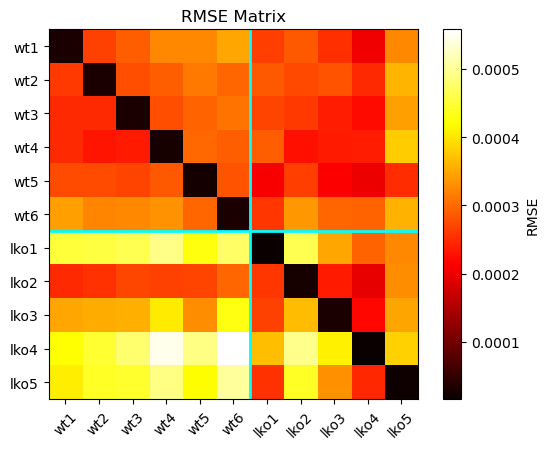

In [34]:
import matplotlib.pyplot as plt

labels = [f"wt{i+1}" for i in range(6)] + [f"lko{i+1}" for i in range(5)]

plt.imshow(rmse_mat, cmap='hot')
plt.colorbar(label='RMSE')

plt.axhline(5.5, color='cyan', linewidth=2)
plt.axvline(5.5, color='cyan', linewidth=2)


plt.xticks(ticks=range(len(labels)), labels=labels, rotation=45)
plt.yticks(ticks=range(len(labels)), labels=labels)

plt.title("RMSE Matrix")
plt.show()

In [70]:
np.ix_(wt_idx, lko_idx)

(array([[0],
        [1],
        [2],
        [3],
        [4],
        [5]]),
 array([[ 6,  7,  8,  9, 10]]))

In [36]:
wt_idx = list(range(5))
lko_idx = list(range(5, 10))

wt_wt = dist_norm[np.ix_(wt_idx, wt_idx)]
lko_lko = dist_norm[np.ix_(lko_idx, lko_idx)]
wt_lko = dist_norm[np.ix_(wt_idx, lko_idx)]
lko_wt = dist_norm[np.ix_(lko_idx, wt_idx)]

print("WT-WT mean:", np.mean(wt_wt))
print("LKO-LKO mean:", np.mean(lko_lko))
print("WT-LKO mean:", np.mean(wt_lko))
print("LKO-WT mean:", np.mean(lko_wt))

WT-WT mean: 0.49009693450690905
LKO-LKO mean: 0.5930452988243968
WT-LKO mean: 0.7672417390804059
LKO-WT mean: 0.8361694453998753


In [75]:
lko_wt

array([[0.81896425, 0.92310519, 0.84549022, 0.999986  , 0.65637668,
        0.75382425],
       [0.64672506, 0.66368373, 0.65467301, 0.62783676, 0.67505985,
        0.79551264],
       [0.79535836, 0.87272055, 0.81210367, 0.91782675, 0.74718889,
        0.99998012],
       [0.67607711, 0.75540579, 0.79169181, 0.93175176, 0.79181923,
        0.9999851 ],
       [0.80866573, 0.94974644, 0.90569494, 0.99998471, 0.7101966 ,
        0.93872395]])

In [37]:
def remove_diag(mat):
    return mat[~np.eye(mat.shape[0], dtype=bool)]

wt_wt_vals = remove_diag(wt_wt)
lko_lko_vals = remove_diag(lko_lko)

print("WT-WT mean:", np.mean(wt_wt_vals))
print("LKO-LKO mean:", np.mean(lko_lko_vals))
print("WT-LKO mean:", np.mean(wt_lko))
print("LKO-WT mean:", np.mean(lko_wt))

WT-WT mean: 0.6126211681336364
LKO-LKO mean: 0.7413066235304961
WT-LKO mean: 0.7672417390804059
LKO-WT mean: 0.8361694453998753


In [38]:
import numpy as np
import open3d as o3d
from scipy.spatial import cKDTree

def chamfer_map(meshA, meshB, n_samples=20000):
    # Sample points
    pcdA = meshA.sample_points_uniformly(number_of_points=n_samples)
    pcdB = meshB.sample_points_uniformly(number_of_points=n_samples)

    ptsA = np.asarray(pcdA.points)
    ptsB = np.asarray(pcdB.points)

    # KDTree
    treeB = cKDTree(ptsB)

    # Distance A → B
    dists, _ = treeB.query(ptsA)

    return pcdA, dists

In [39]:
def colorize_distances(pcd, dists):
    d_norm = (dists - dists.min()) / (dists.max() - dists.min() + 1e-8)

    colors = plt.get_cmap('jet')(d_norm)[:, :3]
    pcd.colors = o3d.utility.Vector3dVector(colors)

    return pcd

## Registration to ATLAS and related plots

In [21]:
import open3d as o3d

mesh_rep = o3d.io.read_triangle_mesh("/home/desktop/Desktop/22104412_Docs/SurfaceRecon/Vein-recons/Registration/cleaned_mesh_atlas.ply")

mesh_rep.compute_triangle_normals()
mesh_rep.compute_vertex_normals()
o3d.visualization.draw_geometries([mesh_rep])

In [22]:
import open3d as o3d
import numpy as np

# -----------------------------
# Utility: PCA
# -----------------------------
def get_pca_axes(mesh):
    points = np.asarray(mesh.vertices)
    centroid = points.mean(axis=0)

    points_centered = points - centroid
    cov = np.cov(points_centered.T)

    eigvals, eigvecs = np.linalg.eigh(cov)
    order = np.argsort(eigvals)[::-1]
    eigvecs = eigvecs[:, order]

    return centroid, eigvecs, points


# -----------------------------
# Utility: local thickness proxy
# -----------------------------
def estimate_local_radius(points, k=20):
    from sklearn.neighbors import NearestNeighbors
    
    nbrs = NearestNeighbors(n_neighbors=k).fit(points)
    distances, _ = nbrs.kneighbors(points)

    # mean neighbor distance as proxy
    radii = distances.mean(axis=1)
    return radii


# -----------------------------
# Utility: straightness
# -----------------------------
def straightness(region):
    if len(region) < 10:
        return 0
    cov = np.cov(region.T)
    eigvals, _ = np.linalg.eigh(cov)
    eigvals = np.sort(eigvals)
    return eigvals[-1] / (eigvals.sum() + 1e-8)


# -----------------------------
# Utility: spread (branchiness proxy)
# -----------------------------
def spread(region):
    if len(region) < 10:
        return 0
    return np.mean(np.linalg.norm(region - region.mean(axis=0), axis=1))


# -----------------------------
# MAIN: Detect A-P direction
# -----------------------------
def detect_AP_axis_atlas(mesh):

    centroid, axes, points = get_pca_axes(mesh)

    major_axis = axes[:, 0]
    minor_axis = axes[:, 2]

    # Project points onto major axis
    proj = (points - centroid) @ major_axis

    # Split ends
    k = int(0.1 * len(points))  # top 10%
    idx_sorted = np.argsort(proj)

    end1_idx = idx_sorted[:k]
    end2_idx = idx_sorted[-k:]

    end1 = points[end1_idx]
    end2 = points[end2_idx]

    # Estimate radii globally (reuse later)
    radii = estimate_local_radius(points)

    r1 = radii[end1_idx]
    r2 = radii[end2_idx]

    # -----------------------------
    # Feature computation
    # -----------------------------
    def compute_score(region, region_radii):
        s = straightness(region)
        t = np.mean(region_radii)
        sp = spread(region)

        # midline closeness (basilar clue)
        mid_dist = np.abs((region - centroid) @ minor_axis)
        mid_score = -np.mean(mid_dist)

        # weighted score
        score = (
            2.0 * s +       # straightness
            1.5 * t +       # thickness
            1.0 * mid_score -  # midline closeness
            1.0 * sp        # penalize spread
        )
        return score

    score1 = compute_score(end1, r1)
    score2 = compute_score(end2, r2)

    # -----------------------------
    # Decide orientation
    # -----------------------------
    if score1 > score2:
        posterior_dir = -major_axis
        anterior_dir  =  major_axis
    else:
        posterior_dir =  major_axis
        anterior_dir  = -major_axis

    return anterior_dir, posterior_dir, centroid

In [ ]:
meshes_scaled = normalize_to_reference(mesh1, mesh_rep)

o3d.visualization.draw_geometries([meshes_scaled, mesh1])

In [ ]:
def registration_to_atlas(mesh1, mesh_rep, window_title):
    mesh2 = normalize_to_reference(mesh1, mesh_rep)
    mesh1.compute_triangle_normals()
    mesh2.compute_triangle_normals()

    mesh1.compute_vertex_normals()
    mesh2.compute_vertex_normals()

    o3d.visualization.draw_geometries([mesh1, mesh2])
    aligned_mesh2 = align_meshes_atlas(mesh2, mesh1)

    
    T = np.eye(4)

    pcdA = mesh1.sample_points_uniformly(100000)
    pcdB = aligned_mesh2.sample_points_uniformly(100000)

    for i in range(10):
        # print(f"\nIteration {i+1}")

        # -------- Point-to-Point (coarse) --------
        reg_p2p = o3d.pipelines.registration.registration_icp(
            pcdB, pcdA,
            2.0,
            T,
            o3d.pipelines.registration.TransformationEstimationPointToPoint()
        )

        T = reg_p2p.transformation

        # -------- Estimate normals ONCE (outside loop is even better) --------
        pcdA.estimate_normals()
        pcdB.estimate_normals()

        # -------- Point-to-Plane (refinement) --------
        reg_p2l = o3d.pipelines.registration.registration_icp(
            pcdB, pcdA,
            2.0,
            T,
            o3d.pipelines.registration.TransformationEstimationPointToPlane()
        )

        T = reg_p2l.transformation

    
    print("Fitness:", reg_p2l.fitness, "RMSE:", reg_p2l.inlier_rmse)

    # Apply final transform ONCE
    pcdB.transform(T)

    aligned_mesh2.transform(T)
    mesh2 = aligned_mesh2

    mesh1.paint_uniform_color([0.5, 0, 0])
    mesh2.paint_uniform_color([0,0,0.5])
    o3d.visualization.draw_geometries([mesh1, mesh2])

    o3d.visualization.draw_geometries(
        [mesh1, mesh2],
        window_name=window_title
)
    
    return mesh1, mesh2

In [84]:
# meshes_scaled.compute_vertex_normals()
# mesh1.compute_vertex_normals()

# aligned_mesh2 = align_meshes_atlas(meshes_scaled, mesh1)

# o3d.visualization.draw_geometries([meshes_scaled, aligned_mesh2])

In [128]:
meshes = [o3d.io.read_triangle_mesh(p) for p in path]

names = [
    os.path.basename(os.path.dirname(p)) + "_" +
    os.path.splitext(os.path.basename(p))[0]
    for p in path
]

N = len(meshes)
dist_tot = []

# -----------------------------
# Compute pairwise distances
# -----------------------------
for i in range(N):
    meshA, meshB = registeration_atlas_basic(meshes[i], mesh_rep)
    # frame_generation(meshA, meshB, f"{names[i]} vs {names[j]}")
    print(f"Completed {i} Mesh")

Fitness: 1.0 RMSE: 0.00046277321905297463
Completed 0 Mesh
Fitness: 1.0 RMSE: 0.00045360597167360257
Completed 1 Mesh
Fitness: 1.0 RMSE: 0.0005029735439493687
Completed 2 Mesh
Fitness: 1.0 RMSE: 0.0004944217870671189
Completed 3 Mesh
Fitness: 1.0 RMSE: 0.0005364728299000265
Completed 4 Mesh
Fitness: 1.0 RMSE: 0.0004516044950515374
Completed 5 Mesh
Fitness: 1.0 RMSE: 0.000505275344577637
Completed 6 Mesh
Fitness: 1.0 RMSE: 0.00041286255875103834
Completed 7 Mesh
Fitness: 1.0 RMSE: 0.0003481362423499439
Completed 8 Mesh
Fitness: 1.0 RMSE: 0.0003913550467512919
Completed 9 Mesh


In [137]:
import numpy as np

rmse = np.array([
    0.00046277321905297463,
    0.00045360597167360257,
    0.0005029735439493687,
    0.0004944217870671189,
    0.0005364728299000265,  # WT (0–4)

    0.0004516044950515374,
    0.000505275344577637,
    0.00041286255875103834,
    0.0003481362423499439,
    0.0003913550467512919   # LKO (5–9)
])

# rmse = np.array([
#     0.00046678,
#     0.00045461,
#     0.00050355,
#     0.00050487,
#     0.00053839,  # WT (first 5)
#     0.00045285,
#     0.00049902,
#     0.00041620,
#     0.00035313,
#     0.00039680   # LKO (last 5)
# ])

# rmse = np.array([
#     0.00046523737495052236,
#     0.00045974662680499113,
#     0.0005049909511679771,
#     0.000496014716129147,
#     0.0005334377677576787,  # WT (0–4)

#     0.0004508523304801968,
#     0.0004999094874725304,
#     0.0004205268331604203,
#     0.00034993142198328034,
#     0.0003936980204769154   # LKO (5–9)
# ])

# rmse =  np.array([
#     0.0004658448327972162,
#     0.0004525648109364056,
#     0.0005040091003480975,
#     0.0004957780135900864,
#     0.000537318063723317,   # WT (0–4)

#     0.0004551396694121663,
#     0.0005021671326499937,
#     0.00041237208643795406,
#     0.0003497070546105646,
#     0.0003925592886641186   # LKO (5–9)
# ])

# rmse = np.array([
#     0.00030785182550207023,
#     0.00032973610725020916,
#     0.00032359195909249555,
#     0.00033082026787732954,
#     0.00030392970424982847,  # WT (0–4)

#     0.00044085431494434867,
#     0.0002961071299455244,
#     0.0003521927999719748,
#     0.0004879948717224397,
#     0.0004108752410367359   # LKO (5–9)
# ])

groups = ["WT"]*5 + ["LKO"]*5

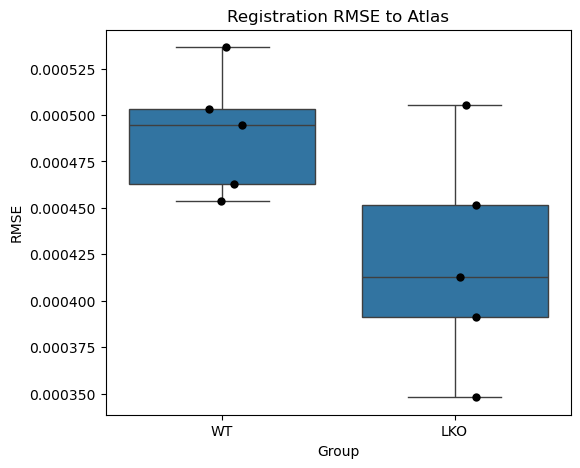

In [138]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "RMSE": rmse,
    "Group": groups
})

plt.figure(figsize=(6,5))

sns.boxplot(data=df, x="Group", y="RMSE")
sns.stripplot(data=df, x="Group", y="RMSE", color='black', size=6)

plt.title("Registration RMSE to Atlas")
plt.ylabel("RMSE")
plt.show()

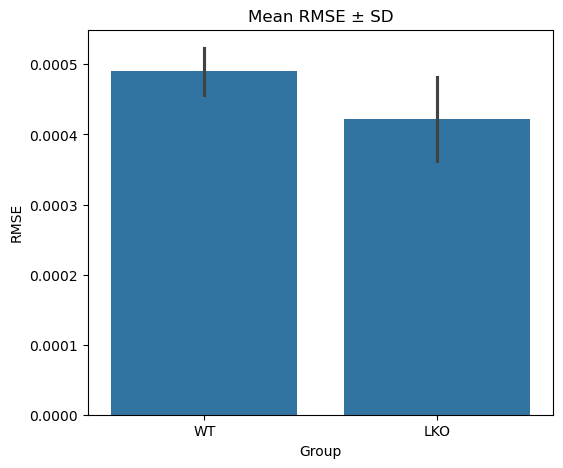

In [139]:
plt.figure(figsize=(6,5))

sns.barplot(data=df, x="Group", y="RMSE", errorbar="sd")

plt.title("Mean RMSE ± SD")
plt.show()

In [132]:
from scipy.stats import mannwhitneyu

wt = rmse[:5]
lko = rmse[5:]

print("WT mean:", wt.mean())
print("LKO mean:", lko.mean())

print(mannwhitneyu(wt, lko))

WT mean: 0.0004900494703286183
LKO mean: 0.00042184673749628965
MannwhitneyuResult(statistic=21.0, pvalue=0.09523809523809523)


In [133]:
from scipy.stats import ttest_ind

wt = rmse[:5]
lko = rmse[5:]

t_stat, p_val = ttest_ind(wt, lko, equal_var=False)  # Welch’s t-test

print("t-stat:", t_stat)
print("p-value:", p_val)

t-stat: 2.230291837752491
p-value: 0.06543185921345895
